# 🗜️ Dimensionality Reduction — PCA, t-SNE and UMAP

> **What you'll learn:** why fewer dimensions often means faster, cleaner and more visual machine learning; how PCA really works (the variance view, the reconstruction view, eigendecomposition vs SVD, choosing components, scaling, whitening); its variants for sparse, huge and nonlinear data; how t-SNE and UMAP draw 2-D maps of high-dimensional data, what those maps can and cannot tell you, and how to compare methods with numbers instead of pretty pictures. You will build PCA from scratch and match scikit-learn exactly.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Clustering: DBSCAN and Gaussian Mixtures](13_Clustering_DBSCAN_and_Gaussian_Mixtures.ipynb) (unsupervised learning, density) · [Math for ML](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) (eigenvectors, SVD, a first look at PCA) · [K-Nearest Neighbors](05_K_Nearest_Neighbors.ipynb) (the curse of dimensionality) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · umap-learn 0.5 · scipy 1.18 · numpy 2.5 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ High — "walk me through PCA", "eigendecomposition or SVD?", "how many components?", "why scale first?", "PCA vs t-SNE vs UMAP", "what can't you read from a t-SNE plot?", "implement PCA in NumPy" |

## 🤔 What Is Dimensionality Reduction?

Think of a **world map**. The Earth is a 3-D ball, but a flat 2-D map is far easier to carry and read. Every flat map distorts *something*: some keep areas right, some keep angles right, and a subway map keeps only "which stop is next to which".

**Dimensionality reduction** does the same for data. Each row of a dataset is a point with one coordinate per feature: a 28×28 image is a point in **784 dimensions**. We look for a much smaller set of numbers per row that keeps what matters.

- **Dimension** = one feature (one column).
- **Projection** = casting a shadow of the data onto fewer axes.
- **Embedding** = the new, low-dimensional coordinates of each point.
- **Manifold** = a lower-dimensional surface the data lives near (a sheet of paper crumpled inside a room is a 2-D manifold in 3-D space).
- **Intrinsic dimension** = how many numbers you really need. Photos of one face turning left and right vary along very few directions, even though each photo has thousands of pixels.

Three methods cover almost every real use:

| Method | The map it draws | Like… |
|---|---|---|
| **PCA** | the best *flat shadow*: straight axes that keep the most variance | a photo of a sculpture from its most informative angle |
| **t-SNE** | a map that keeps each point's *close neighbours* close | a subway map: neighbourhoods right, distances wrong |
| **UMAP** | a neighbour-keeping map built from a graph, faster and able to place new points | a subway map you can add new stations to |

## 🎯 Why It Matters

- **Visualization.** Humans see 2 or 3 dimensions. Plotting embeddings (of images, customers, documents or LLM embeddings) is the first step of almost every exploratory analysis and model debugging session.
- **Speed and memory.** 784 pixels → 50 components shrinks data 15× and makes distance-based models and training loops much faster.
- **Noise removal.** The last components often hold mostly noise; dropping them can *improve* a model.
- **Fighting the curse of dimensionality.** Distances lose meaning in high dimensions ([K-Nearest Neighbors, Section 7](05_K_Nearest_Neighbors.ipynb)), so reducing first helps KNN, clustering and anomaly detection.
- **In production:** PCA for compressing embeddings before a vector index, whitening features, monitoring drift with reconstruction error, LSA (TruncatedSVD) for text search, UMAP maps in data-labelling and embedding-exploration tools.
- **In interviews** it is a classic: *"walk me through PCA"*, *"why SVD instead of the covariance matrix?"*, *"how many components would you keep?"*, *"PCA vs t-SNE vs UMAP?"*, *"a t-SNE plot shows two clusters far apart. What can you conclude?"*, *"implement PCA with NumPy"*. This notebook practises every one.

## 🃏 Algorithm Card

One card, a column per method, same rows as every notebook in the series.

| | PCA | t-SNE | UMAP |
|---|---|---|---|
| **Learning type** | Unsupervised, linear, parametric (a fixed projection matrix) | Unsupervised, nonlinear, non-parametric (only coordinates for the points it saw) | Unsupervised (optionally supervised), nonlinear, graph-based; learns a reusable mapping |
| **Tasks** | Compression, denoising, decorrelation/whitening, speed-up before other models, 2-D views, anomaly scores via reconstruction error | 2-D/3-D visualization of local structure | Visualization, reduction to 5–50 dims before clustering or KNN, supervised metric learning |
| **Model / objective** | Maximize projected variance $\max_{W^\top W=I} \operatorname{tr}(W^\top S W)$ ⇔ minimize reconstruction error $\lVert X_c - X_c W W^\top\rVert_F^2$ | Minimize $\mathrm{KL}(P\,\Vert\,Q)$ between Gaussian neighbour probabilities in high-D and Student-t probabilities in low-D | Minimize fuzzy cross-entropy between a high-D k-nearest-neighbour graph and a low-D graph (attractive + repulsive terms) |
| **Key hyperparameters (typical ranges)** | `n_components` (int or variance share like 0.95), `whiten`, `svd_solver` | `perplexity` (5–50, must be < n), `early_exaggeration` (12), `learning_rate` (`"auto"`), `max_iter` (1,000), `init` (`"pca"`), `random_state` | `n_neighbors` (5–100, local ↔ global), `min_dist` (0.0–0.99, packing), `n_components` (2–50), `metric`, `random_state` |
| **Needs feature scaling?** | **Yes** when features have different units (standardize); usually not for same-unit data like pixels | Yes for mixed units (it uses distances); often run on the top ~50 PCA components | Yes for mixed units; choose a `metric` that fits the data (euclidean, cosine…) |
| **Handles missing values / categoricals?** | No / no — impute and encode first | No / no | No / no, though custom metrics (e.g. Hamming, Jaccard) can handle binary data |
| **Training & prediction complexity** | Full SVD O(n·d·min(n,d)); covariance route O(n·d² + d³); randomized O(n·d·k). Transform O(d·k) per row | Barnes–Hut O(n log n) per iteration × ~1,000 iterations; memory O(n·perplexity). **No transform** for new points | Approximate kNN graph (NN-descent, roughly O(n^1.14) empirically) + O(n·k) per epoch; transform available but slower than fitting a linear map |
| **Interpretability** | High: components are weighted sums of the original features (loadings), and explained variance is exact | Low: axes, cluster sizes and between-cluster distances are meaningless | Low–medium: axes arbitrary, local neighbourhoods meaningful, global layout only roughly |
| **Strengths** | Fast, deterministic, exact inverse transform, well understood, works on millions of rows | Beautiful separation of local clusters, robust default settings | Fast, scales to millions of points, `transform` on new data, supervised mode, good for reduction before clustering |
| **Weaknesses** | Linear only; high variance ≠ importance; sensitive to scaling and outliers | Slow on big data, stochastic, distorts sizes and distances, no transform, visual only | Stochastic, distorts densities and distances, many knobs, embeddings can create false clusters |
| **Use it when** | Compressing or decorrelating features, speeding up models, a first 2-D look, denoising | Exploring clusters in ≤ ~100k points for a figure | Visualizing big data, embedding new points later, reducing before HDBSCAN/KNN |
| **Avoid it when** | Structure is strongly nonlinear and you need a 2-D picture; features are sparse counts (use TruncatedSVD) | You need features for a model, distances between clusters, or to embed new data | You need exact distances, reproducible deterministic outputs, or interpretable axes |
| **Best libraries** | scikit-learn (`PCA`, `IncrementalPCA`, `TruncatedSVD`, `KernelPCA`), NumPy/SciPy SVD | scikit-learn `TSNE`, openTSNE (faster, supports adding points) | umap-learn (`umap.UMAP`), cuML on GPUs |

## ✅ By the End You Can

- [ ] Explain PCA as both maximum variance and minimum reconstruction error, and derive it from eigenvectors of the covariance or the SVD
- [ ] Choose the number of components with explained variance and with cross-validation inside a `Pipeline`, and explain why scaling and whitening matter
- [ ] Pick the right variant: `TruncatedSVD` for sparse text, `IncrementalPCA` for data that doesn't fit in memory, `KernelPCA` for nonlinear structure
- [ ] Tune t-SNE and UMAP, and list what you must **not** read from their plots
- [ ] Compare embeddings with trustworthiness, kNN accuracy and runtime instead of eyeballing
- [ ] Implement PCA from scratch with NumPy's SVD (plus power iteration) and match scikit-learn exactly

## 📋 Table of Contents

1. [Why Reduce Dimensions?](#1.-Why-Reduce-Dimensions?-🟢)
2. [PCA: Two Views of the Same Answer](#2.-PCA:-Two-Views-of-the-Same-Answer-🟢)
3. [The Math: Covariance Eigendecomposition vs SVD](#3.-The-Math:-Covariance-Eigendecomposition-vs-SVD-🟡)
4. [Choosing the Number of Components](#4.-Choosing-the-Number-of-Components-🟡)
5. [Why Scaling Matters](#5.-Why-Scaling-Matters-🟢)
6. [Eigenfaces: Reconstruction and Whitening](#6.-Eigenfaces:-Reconstruction-and-Whitening-🟡)
7. [PCA Inside a Pipeline, Tuned by Cross-Validation](#7.-PCA-Inside-a-Pipeline,-Tuned-by-Cross-Validation-🟡)
8. [PCA Variants: TruncatedSVD, IncrementalPCA, KernelPCA](#8.-PCA-Variants:-TruncatedSVD,-IncrementalPCA,-KernelPCA-🟡)
9. [Assumptions and When They Break](#9.-Assumptions-and-When-They-Break-🟡)
10. [t-SNE: Perplexity, Crowding and KL Divergence](#10.-t-SNE:-Perplexity,-Crowding-and-KL-Divergence-🟡)
11. [What NOT to Read From a t-SNE Plot](#11.-What-NOT-to-Read-From-a-t-SNE-Plot-🔴)
12. [UMAP: Neighbours, min_dist, transform and Supervision](#12.-UMAP:-Neighbours,-min_dist,-transform-and-Supervision-🟡)
13. [UMAP Before Clustering, With Caveats](#13.-UMAP-Before-Clustering,-With-Caveats-🔴)
14. [A Fair Head-to-Head: PCA vs t-SNE vs UMAP](#14.-A-Fair-Head-to-Head:-PCA-vs-t-SNE-vs-UMAP-🟡)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Compress-and-Classify-Fashion-MNIST) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real):** wine chemistry and 8×8 handwritten digits ship with scikit-learn. **Fashion-MNIST** (70,000 clothing photos, OpenML, ~30 MB), the **Olivetti faces** (400 photos of 40 people, ~4 MB) and **20 Newsgroups** (~14 MB of forum posts) are downloaded once and cached in `_outputs/sklearn_data/`. t-SNE and UMAP run on subsamples of a few thousand images so the whole notebook stays within a few minutes and modest memory.

**UMAP note:** `umap-learn` compiles its code with numba the first time it runs, which adds several seconds once. Passing `random_state` makes results reproducible but runs UMAP single-threaded; we also pass `n_jobs=1` to say so explicitly.

In [1]:
# %pip install -q "scikit-learn>=1.6" "umap-learn>=0.5" "scipy>=1.11" "pandas>=2.2" matplotlib

import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import umap
from scipy.stats import spearmanr
from sklearn.cluster import HDBSCAN, KMeans
from sklearn.datasets import fetch_20newsgroups, fetch_olivetti_faces, fetch_openml, load_digits, load_wine, make_circles
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix, pairwise_distances, silhouette_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.svm import SVC

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | umap-learn {umap.__version__} | "
      f"scipy {scipy.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # dataset download cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | umap-learn 0.5.12 | scipy 1.18.1 | numpy 2.5.3 | pandas 3.0.5


In [2]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target.to_numpy()
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
faces = fetch_olivetti_faces(data_home=DATA_HOME, shuffle=True, random_state=SEED)
X_faces, y_faces = faces.data.astype(np.float64), faces.target
X_fashion_all, y_fashion_all = fetch_openml(data_id=40996, as_frame=False, return_X_y=True, data_home=DATA_HOME, parser="pandas")
X_fashion_all = (X_fashion_all / 255.0).astype(np.float32)   # pixels 0–255 → 0–1; float32 halves memory
y_fashion_all = y_fashion_all.astype(int)
gc.collect()
fashion_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"wine          : {X_wine.shape}  3 cultivars, 13 chemical measurements in different units")
print(f"digits        : {X_digits.shape}  8×8 images, 10 classes")
print(f"Olivetti faces: {X_faces.shape}  64×64 images of {len(np.unique(y_faces))} people, pixels in [0, 1]")
print(f"Fashion-MNIST : {X_fashion_all.shape}  28×28 images, 10 classes, {X_fashion_all.nbytes / 1e6:.0f} MB as float32")

wine          : (178, 13)  3 cultivars, 13 chemical measurements in different units
digits        : (1797, 64)  8×8 images, 10 classes
Olivetti faces: (400, 4096)  64×64 images of 40 people, pixels in [0, 1]
Fashion-MNIST : (70000, 784)  28×28 images, 10 classes, 220 MB as float32


## 1. Why Reduce Dimensions? 🟢

Four reasons, each shown with numbers later in this notebook:

1. **Visualization** — we can only look at 2 or 3 axes (Sections 10–14).
2. **Speed and memory** — fewer columns means faster distances, training and serving (Sections 7 and the Mini Project).
3. **Noise** — small-variance directions are often noise; dropping them can help (Section 6).
4. **The curse of dimensionality** — in many dimensions, distances concentrate and "nearest" loses meaning. We measured this in [K-Nearest Neighbors, Section 7](05_K_Nearest_Neighbors.ipynb); reducing dimensions is one of the main cures.

There are two families of methods:

| | **Feature selection** | **Feature extraction** |
|---|---|---|
| What it does | keeps a **subset** of the original columns | builds **new** columns as combinations of all the old ones |
| Examples | `SelectKBest`, L1 regularization, tree importances (notebook 16) | PCA, TruncatedSVD, t-SNE, UMAP, autoencoders |
| Interpretability | high: "we kept alcohol and flavanoids" | lower: "component 1 = 0.39·flavanoids + 0.37·phenols + …" |
| Still needs all raw features at prediction time? | no | yes |

Let's compare both on the wine data with **the same 5 folds**: all 13 features, the 2 best original features, and 2 principal components. Everything is inside a pipeline, so each fold learns its own scaling, selection and PCA.

In [3]:
wine_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
reduction_models = {
    "all 13 features": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "selection: 2 best original features": make_pipeline(StandardScaler(), SelectKBest(f_classif, k=2), KNeighborsClassifier()),
    "extraction: 2 principal components": make_pipeline(StandardScaler(), PCA(n_components=2), KNeighborsClassifier()),
}
reduction_scores = pd.Series({name: cross_val_score(model, X_wine, y_wine, cv=wine_folds).mean()
                              for name, model in reduction_models.items()}, name="5-fold KNN accuracy")
print(reduction_scores.round(3))

selector = reduction_models["selection: 2 best original features"].fit(X_wine, y_wine)[1]
selected = X_wine.columns[selector.get_support()]
pc1 = make_pipeline(StandardScaler(), PCA(n_components=2)).fit(X_wine)[1].components_[0]
print(f"\nselection kept: {list(selected)}")
print(f"extraction's component 1 uses all 13 features; the 3 largest weights: "
      f"{dict(pd.Series(pc1, index=X_wine.columns).abs().nlargest(3).round(2))}")
gap = reduction_scores.iloc[2] - reduction_scores.iloc[1]
print(f"\n2 principal components vs 2 selected features: {gap:+.3f} accuracy → "
      f"{'combining all features into 2 new ones kept more information here' if gap > 0 else 'the 2 best raw features were enough here'}.")

all 13 features                        0.972
selection: 2 best original features    0.831
extraction: 2 principal components     0.967
Name: 5-fold KNN accuracy, dtype: float64

selection kept: ['flavanoids', 'proline']
extraction's component 1 uses all 13 features; the 3 largest weights: {'flavanoids': np.float64(0.42), 'total_phenols': np.float64(0.39), 'od280/od315_of_diluted_wines': np.float64(0.38)}

2 principal components vs 2 selected features: +0.135 accuracy → combining all features into 2 new ones kept more information here.


### ✍️ Your Turn

Fashion-MNIST has `n = 70,000` images with `d = 784` pixels each. If we keep `k = 50` principal components, we store `n × k` scores **plus** the model: `k × d` component weights and a `d`-long mean. Compute the storage **compression ratio** `(n·d) / (n·k + k·d + d)`.

In [4]:
n_images, n_pixels, k_kept = 70_000, 784, 50
compression_ratio = None  # TODO: your code here
check("compression_ratio", compression_ratio, 15.5028949, hint="(n_images * n_pixels) / (n_images * k_kept + k_kept * n_pixels + n_pixels)")

⏳ compression_ratio: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_images, n_pixels, k_kept = 70_000, 784, 50
compression_ratio = (n_images * n_pixels) / (n_images * k_kept + k_kept * n_pixels + n_pixels)
check("compression_ratio", compression_ratio, 15.5028949)
```

About 15.5× smaller. The model itself (components + mean) is tiny compared with the data, so the ratio is close to `d / k = 15.68`.
</details>

> 💡 **Interview angle:** "Feature selection or feature extraction?" — selection keeps original, interpretable columns (and you can stop collecting the others); extraction like PCA builds new combined features that usually keep more information in fewer dimensions but are harder to explain and still need every raw feature at prediction time.

## 2. PCA: Two Views of the Same Answer 🟢

**Principal Component Analysis (PCA)** finds new axes, called **principal components**, ordered by how much of the data's spread they capture. There are two ways to say what "best axis" means, and they give the same answer:

1. **Variance view:** choose the direction along which the projected points are **most spread out** (maximum variance).
2. **Reconstruction view:** choose the direction whose projection **loses the least** when you rebuild each point from it (minimum squared reconstruction error).

Why the same? For a centered point $x$ and a unit direction $u$, Pythagoras splits its squared length into the part along $u$ and the part left over:

$$\lVert x\rVert^2 = \underbrace{(x^\top u)^2}_{\text{kept (projected variance)}} + \underbrace{\lVert x - (x^\top u)\,u\rVert^2}_{\text{lost (reconstruction error)}}$$

The left side doesn't depend on $u$, so **maximizing what you keep = minimizing what you lose**. Formally, with covariance matrix $S = \frac{1}{n-1}X_c^\top X_c$:

$$\max_{\lVert u\rVert = 1} u^\top S u \;\;\Rightarrow\;\; \text{Lagrangian } u^\top S u - \lambda(u^\top u - 1) \;\;\Rightarrow\;\; S u = \lambda u$$

The best direction is the **eigenvector with the largest eigenvalue**, and that eigenvalue *is* the variance along it. The next component is the best direction orthogonal to the first, and so on.

We test this by brute force on two real wine measurements that move together: **total phenols** and **flavanoids** (both concentrations; centered, not standardized). We try every angle from 0° to 180°.

In [5]:
two_cols = ["total_phenols", "flavanoids"]
X_two = X_wine[two_cols].to_numpy()
Xc_two = X_two - X_two.mean(axis=0)

angles = np.arange(0, 180, 0.25)
directions = np.column_stack([np.cos(np.radians(angles)), np.sin(np.radians(angles))])   # (720, 2) unit vectors
proj = Xc_two @ directions.T                                                             # (178, 720) projections
proj_var = proj.var(axis=0)                                                              # variance kept per angle
recon_err = ((Xc_two[:, :, None] - proj[:, None, :] * directions.T[None, :, :]) ** 2).sum(axis=1).mean(axis=0)

pca_two = PCA(n_components=2).fit(X_two)
pc1_angle = np.degrees(np.arctan2(pca_two.components_[0, 1], pca_two.components_[0, 0])) % 180
best_var_angle, best_err_angle = angles[proj_var.argmax()], angles[recon_err.argmin()]
total_var = Xc_two.var(axis=0).sum()

assert np.allclose(proj_var + recon_err, total_var)               # kept + lost = total, for every angle
assert abs(best_var_angle - pc1_angle) <= 0.25 and abs(best_err_angle - pc1_angle) <= 0.25
print(f"max-variance angle {best_var_angle:.2f}° | min-error angle {best_err_angle:.2f}° | sklearn PC1 angle {pc1_angle:.2f}°")
print(f"PC1 keeps {pca_two.explained_variance_ratio_[0]:.1%} of the total variance; kept + lost = total at every angle ✅")

max-variance angle 59.75° | min-error angle 59.75° | sklearn PC1 angle 59.64°
PC1 keeps 94.6% of the total variance; kept + lost = total at every angle ✅


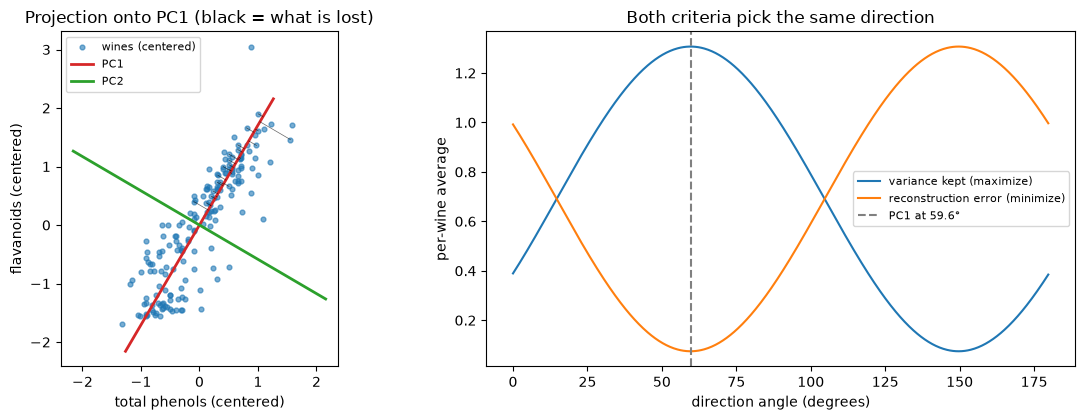

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ax = axes[0]
ax.scatter(*Xc_two.T, s=12, alpha=0.6, label="wines (centered)")
for vec, name, color in [(pca_two.components_[0], "PC1", "tab:red"), (pca_two.components_[1], "PC2", "tab:green")]:
    ax.plot(*np.outer([-2.5, 2.5], vec).T, color=color, lw=2, label=name)
proj_points = np.outer(Xc_two[:25] @ pca_two.components_[0], pca_two.components_[0])
for p, q in zip(Xc_two[:25], proj_points):
    ax.plot([p[0], q[0]], [p[1], q[1]], "k-", lw=0.5, alpha=0.6)
ax.set(xlabel="total phenols (centered)", ylabel="flavanoids (centered)", title="Projection onto PC1 (black = what is lost)", aspect="equal")
ax.legend(fontsize=8)
ax = axes[1]
ax.plot(angles, proj_var, label="variance kept (maximize)")
ax.plot(angles, recon_err, label="reconstruction error (minimize)")
ax.axvline(pc1_angle, ls="--", c="grey", label=f"PC1 at {pc1_angle:.1f}°")
ax.set(xlabel="direction angle (degrees)", ylabel="per-wine average", title="Both criteria pick the same direction")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

`M` is already centered. Compute the **sample variance** (`ddof=1`, as scikit-learn's `explained_variance_` uses) of its projection onto the unit direction `u = [0.6, 0.8]`.

In [7]:
M = np.array([[2.0, 1.0], [-2.0, -1.0], [1.0, 2.0], [-1.0, -2.0]])
u_dir = np.array([0.6, 0.8])
projected_variance = None  # TODO: your code here
check("projected_variance", projected_variance, 5.8933333, hint="(M @ u_dir).var(ddof=1)")

⏳ projected_variance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
M = np.array([[2.0, 1.0], [-2.0, -1.0], [1.0, 2.0], [-1.0, -2.0]])
u_dir = np.array([0.6, 0.8])
projected_variance = (M @ u_dir).var(ddof=1)
check("projected_variance", projected_variance, 5.8933333)
```

The projections are `[2.0, -2.0, 2.2, -2.2]`; their squares sum to 17.68, divided by `n − 1 = 3`. Equivalently `u_dir @ np.cov(M, rowvar=False) @ u_dir`, the quadratic form $u^\top S u$ that PCA maximizes.
</details>

> 💡 **Interview angle:** "What does PCA optimize?" — two equivalent things: the variance of the projected data (maximize) and the squared reconstruction error (minimize), because kept + lost = total by Pythagoras. The solution is the top eigenvectors of the covariance matrix; each eigenvalue is the variance along its component.

## 3. The Math: Covariance Eigendecomposition vs SVD 🟡

[Math for ML, Section 8](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) showed that both routes give the same components on the digits. Here we go deeper: **cost, numerical stability and signs**.

| Route | Steps | Cost | Notes |
|---|---|---|---|
| **Covariance eigendecomposition** | $S = X_c^\top X_c/(n-1)$, then `eigh(S)` | O(n·d²) to build $S$ + O(d³) to decompose | great when d is small and n is huge; squares the condition number |
| **SVD of the data** | $X_c = U\Sigma V^\top$; components = rows of $V^\top$, variances $= s^2/(n-1)$ | O(n·d·min(n, d)) | numerically stable; works when d > n (faces: 4,096 pixels, 300 photos) |
| **Randomized SVD** | project onto a random k-dim subspace, refine with a few power iterations | O(n·d·k) | fast for the top k on big matrices; approximate |
| **ARPACK / Lanczos** | iterative, only needs matrix–vector products | depends on k and the spectrum | good for sparse or very wide data, small k |

Scikit-learn's `PCA(svd_solver=...)` exposes `"full"`, `"covariance_eigh"`, `"randomized"` and `"arpack"`; `"auto"` picks one from the data shape. The scores are $Z = X_c V_k = U_k \Sigma_k$: the SVD hands you the projected data for free.

Let's time them on 20,000 Fashion-MNIST images (784 pixels) for 50 components and check they agree.

In [8]:
X_f20k = X_fashion_all[:20_000].astype(np.float64)
solver_rows, solver_fits = [], {}
for solver in ["full", "covariance_eigh", "randomized", "arpack"]:
    start = time.perf_counter()
    fitted = PCA(n_components=50, svd_solver=solver, random_state=SEED).fit(X_f20k)
    solver_fits[solver] = fitted
    solver_rows.append({"svd_solver": solver, "fit seconds": time.perf_counter() - start,
                        "variance kept by 50 components": fitted.explained_variance_ratio_.sum()})
reference = solver_fits["full"]
for row in solver_rows:
    fitted = solver_fits[row["svd_solver"]]
    row["max relative error in eigenvalues"] = np.max(np.abs(fitted.explained_variance_ / reference.explained_variance_ - 1))
    row["min |cos| with 'full' (first 10 comps)"] = np.min(np.abs((fitted.components_[:10] * reference.components_[:10]).sum(axis=1)))
solver_table = pd.DataFrame(solver_rows).set_index("svd_solver")
print(solver_table.to_string(float_format=lambda v: f"{v:.6g}"))
auto_choice = PCA(n_components=50).fit(X_f20k)._fit_svd_solver
print(f"\nfastest: {solver_table['fit seconds'].idxmin()} | 'auto' chose '{auto_choice}' for a {X_f20k.shape[0]:,} × {X_f20k.shape[1]} matrix")
del solver_fits
_ = gc.collect()

                 fit seconds  variance kept by 50 components  max relative error in eigenvalues  min |cos| with 'full' (first 10 comps)
svd_solver                                                                                                                             
full                0.702166                        0.862558                                  0                                       1
covariance_eigh    0.0633493                        0.862558                        7.81597e-14                                       1
randomized          0.162629                        0.862508                         0.00684651                                       1
arpack              0.333802                        0.862558                        2.04281e-14                                       1

fastest: covariance_eigh | 'auto' chose 'covariance_eigh' for a 20,000 × 784 matrix


**Why not always use the covariance?** Forming $X^\top X$ **squares the condition number**, so tiny singular values are lost to rounding. The classic textbook demonstration is the Läuchli matrix (a controlled example with a known answer): its smallest singular value is exactly $\varepsilon = 10^{-8}$, but $\varepsilon^2 = 10^{-16}$ disappears when added to 1 in float64.

In [9]:
eps = 1e-8
lauchli = np.array([[1.0, 1.0], [eps, 0.0], [0.0, eps]])
sv_from_svd = np.linalg.svd(lauchli, compute_uv=False)
eig_of_gram = np.linalg.eigvalsh(lauchli.T @ lauchli)[::-1]
sv_from_eig = np.sqrt(np.clip(eig_of_gram, 0, None))
print("true singular values        : [1.41421356e+00 1.00000000e-08]")
print("np.linalg.svd(X)            :", sv_from_svd)
print("sqrt(eigvalsh(XᵀX))         :", sv_from_eig, "| raw eigenvalues:", eig_of_gram)
print(f"SVD recovers ε: {np.isclose(sv_from_svd[1], eps, rtol=1e-3, atol=0)} | covariance route recovers ε: {np.isclose(sv_from_eig[1], eps, rtol=1e-3, atol=0)}")

true singular values        : [1.41421356e+00 1.00000000e-08]
np.linalg.svd(X)            : [1.41421356e+00 1.00000000e-08]
sqrt(eigvalsh(XᵀX))         : [1.41421356 0.        ] | raw eigenvalues: [2. 0.]
SVD recovers ε: True | covariance route recovers ε: False


**Signs are arbitrary.** If $v$ is an eigenvector, so is $-v$. Different libraries (or versions) can return flipped components, which flips the sign of the scores but changes nothing real. Scikit-learn makes the output deterministic with `svd_flip`: in each component, the entry with the **largest absolute value is made positive**. Keep this in mind when comparing components (Pitfall 4).

### ✍️ Your Turn

A centered data matrix has singular values `s = [6, 3, 2, 1]`. Compute the **explained variance ratio** of each component.

In [10]:
s_values = np.array([6.0, 3.0, 2.0, 1.0])
ratio_from_s = None  # TODO: your code here
check("ratio_from_s", ratio_from_s, [0.72, 0.18, 0.08, 0.02], hint="Variance ∝ s²; divide s**2 by its sum (the n − 1 cancels).")

⏳ ratio_from_s: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
s_values = np.array([6.0, 3.0, 2.0, 1.0])
ratio_from_s = s_values ** 2 / (s_values ** 2).sum()
check("ratio_from_s", ratio_from_s, [0.72, 0.18, 0.08, 0.02])
```

The variance along component j is $s_j^2/(n-1)$; the $(n-1)$ cancels in the ratio: `[36, 9, 4, 1] / 50`.
</details>

> 💡 **Interview angle:** "Eigendecomposition of the covariance or SVD?" — they give the same components (eigenvalues = s²/(n−1)), but SVD works on the data directly, never forms XᵀX (which squares the condition number), handles d > n naturally, and gives the scores U·Σ for free. Covariance + `eigh` is fine and fast when d is small and n is huge; randomized SVD when you only need the top k of a big matrix.

## 4. Choosing the Number of Components 🟡

Three common approaches, from quick to principled:

1. **Explained variance threshold:** keep the smallest k whose cumulative explained variance reaches 90%, 95% or 99%. In scikit-learn, pass a float: `PCA(n_components=0.95)`.
2. **Scree plot / elbow:** plot the variance of each component and stop where the curve flattens. Subjective, but a useful picture. For **standardized** data a classic rule of thumb (Kaiser) keeps components with eigenvalue > 1, i.e. those carrying more than one original feature's worth of variance.
3. **Downstream performance:** treat k as a hyperparameter and **cross-validate** the whole pipeline (Section 7). This is the right answer whenever PCA feeds a model.

components needed on Fashion-MNIST (784 pixels): {'80%': 24, '90%': 84, '95%': 186, '99%': 455}
PCA(n_components=0.95) keeps 186 components ✅ (same as the cumulative-sum rule)
wine, standardized: Kaiser rule (eigenvalue > 1) keeps 3 of 13 components (67% of the variance)


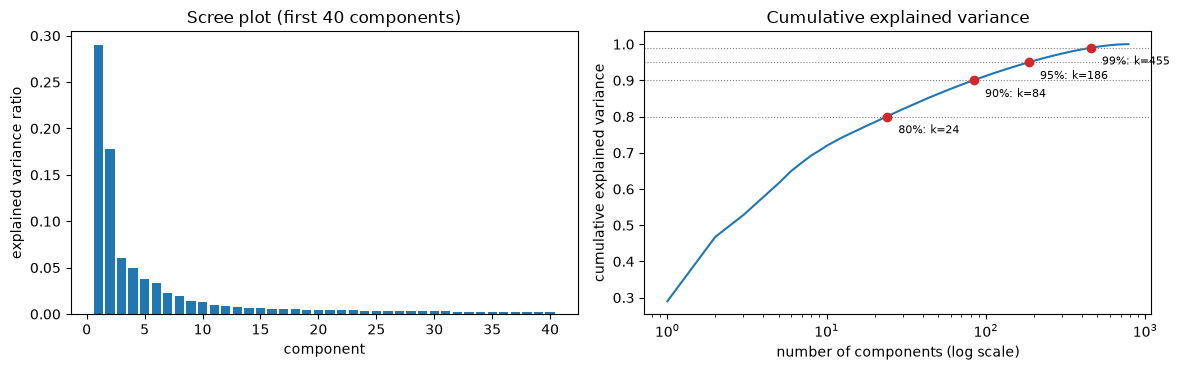

In [11]:
pca_fashion = PCA().fit(X_f20k)
ratio = pca_fashion.explained_variance_ratio_
cumulative = np.cumsum(ratio)
k_for = {t: int(np.searchsorted(cumulative, t) + 1) for t in [0.80, 0.90, 0.95, 0.99]}
k95_sklearn = PCA(n_components=0.95).fit(X_f20k).n_components_
assert k_for[0.95] == k95_sklearn
print("components needed on Fashion-MNIST (784 pixels):", {f"{t:.0%}": k for t, k in k_for.items()})
print(f"PCA(n_components=0.95) keeps {k95_sklearn} components ✅ (same as the cumulative-sum rule)")

wine_std_eigen = make_pipeline(StandardScaler(), PCA()).fit(X_wine)[1].explained_variance_
print(f"wine, standardized: Kaiser rule (eigenvalue > 1) keeps {(wine_std_eigen > 1).sum()} of 13 components "
      f"({np.cumsum(wine_std_eigen / wine_std_eigen.sum())[(wine_std_eigen > 1).sum() - 1]:.0%} of the variance)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(np.arange(1, 41), ratio[:40])
axes[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree plot (first 40 components)")
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative)
for t, k in k_for.items():
    axes[1].axhline(t, ls=":", c="grey", lw=0.8)
    axes[1].plot(k, t, "o", c="tab:red")
    axes[1].annotate(f"{t:.0%}: k={k}", (k, t), textcoords="offset points", xytext=(8, -12), fontsize=8)
axes[1].set(xscale="log", xlabel="number of components (log scale)", ylabel="cumulative explained variance",
            title="Cumulative explained variance")
plt.tight_layout()
plt.show()

Going from 95% to 99% of the variance costs many more components: the tail is long and mostly fine detail and noise. Whether you *need* that detail depends on the task, which is why Section 7 and the Mini Project choose k with a model score.

### ✍️ Your Turn

Given the cumulative explained variance below, find the **smallest number of components** `k_95` that keeps at least 95%.

In [12]:
cum_example = np.array([0.42, 0.71, 0.88, 0.94, 0.97, 0.99, 1.00])
k_95 = None  # TODO: your code here
check("k_95", k_95, 5, hint="np.argmax(cum_example >= 0.95) gives a 0-based index; add 1 to turn it into a count.")

⏳ k_95: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cum_example = np.array([0.42, 0.71, 0.88, 0.94, 0.97, 0.99, 1.00])
k_95 = int(np.argmax(cum_example >= 0.95) + 1)
check("k_95", k_95, 5)
```

Index 4 is the first value ≥ 0.95 (0.97), so 5 components. The classic off-by-one bug is returning the index instead of the count.
</details>

> 💡 **Interview angle:** "How do you choose the number of components?" — for compression or a quick look, the smallest k reaching ~95% explained variance (`PCA(n_components=0.95)`) or the scree elbow; when PCA feeds a model, tune k with cross-validation of the full pipeline, because variance kept is not the same as predictive information.

## 5. Why Scaling Matters 🟢

PCA chases **variance**, and variance depends on **units**. In the wine data, **proline** is measured in the hundreds to thousands, while **hue** stays below 2. Without scaling, "the direction of largest variance" is simply "the proline axis": PCA has learned nothing about the chemistry.

Rule: **standardize** (mean 0, standard deviation 1) when features have different units. When all features share one unit and their scale is meaningful (pixels, word counts), you usually don't standardize, because that would give rarely-used, almost-constant pixels the same weight as the informative ones.

In [13]:
raw_pca = PCA().fit(X_wine)
std_pca = make_pipeline(StandardScaler(), PCA()).fit(X_wine)[1]
loadings = pd.DataFrame({"raw PC1 weight": raw_pca.components_[0], "standardized PC1 weight": std_pca.components_[0],
                         "feature std": X_wine.std()}, index=X_wine.columns)
print(loadings.reindex(loadings["raw PC1 weight"].abs().sort_values(ascending=False).index).head(5).round(3))
print(f"\nPC1 explains {raw_pca.explained_variance_ratio_[0]:.1%} of the variance on raw data "
      f"vs {std_pca.explained_variance_ratio_[0]:.1%} after standardizing")

acc_raw = cross_val_score(make_pipeline(PCA(n_components=2), KNeighborsClassifier()), X_wine, y_wine, cv=wine_folds).mean()
acc_std = cross_val_score(make_pipeline(StandardScaler(), PCA(n_components=2), KNeighborsClassifier()), X_wine, y_wine, cv=wine_folds).mean()
print(f"KNN on 2 components, 5-fold accuracy: raw {acc_raw:.3f} | standardized {acc_std:.3f} ({acc_std - acc_raw:+.3f})")

                   raw PC1 weight  standardized PC1 weight  feature std
proline                     1.000                    0.287      314.907
magnesium                   0.018                    0.142       14.282
alcalinity_of_ash          -0.005                   -0.239        3.340
color_intensity             0.002                   -0.089        2.318
alcohol                     0.002                    0.144        0.812

PC1 explains 99.8% of the variance on raw data vs 36.2% after standardizing
KNN on 2 components, 5-fold accuracy: raw 0.669 | standardized 0.967 (+0.298)


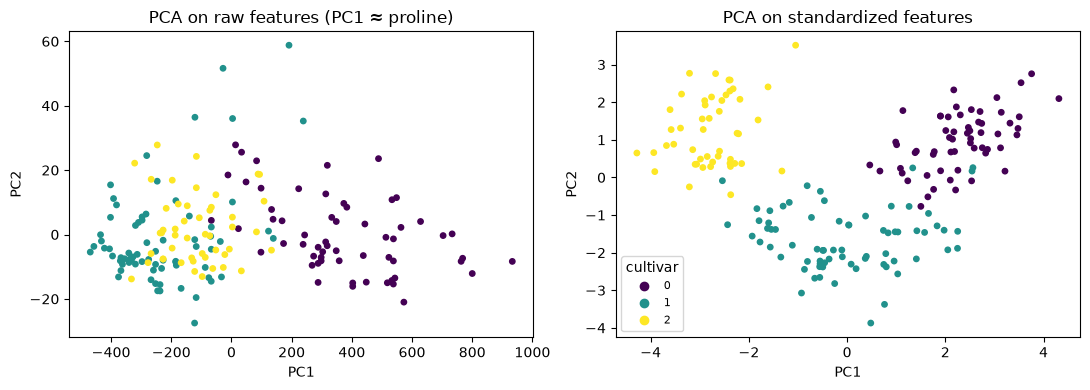

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pipe, title in [(axes[0], PCA(n_components=2), "PCA on raw features (PC1 ≈ proline)"),
                        (axes[1], make_pipeline(StandardScaler(), PCA(n_components=2)), "PCA on standardized features")]:
    Z = pipe.fit_transform(X_wine)
    scatter = ax.scatter(*Z.T, c=y_wine, cmap="viridis", s=15)
    ax.set(xlabel="PC1", ylabel="PC2", title=title)
axes[1].legend(*scatter.legend_elements(), title="cultivar", fontsize=8)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Fit `PCA` on the **raw** wine features and return the **name** of the feature with the largest absolute weight in the first component.

In [15]:
dominant_feature = None  # TODO: your code here
check("dominant_feature", dominant_feature, "proline", hint="X_wine.columns[np.abs(PCA(n_components=1).fit(X_wine).components_[0]).argmax()]")

⏳ dominant_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dominant_feature = X_wine.columns[np.abs(PCA(n_components=1).fit(X_wine).components_[0]).argmax()]
check("dominant_feature", dominant_feature, "proline")
```

Proline's standard deviation (~315) dwarfs every other feature's, so it alone defines the "largest variance" direction.
</details>

> 💡 **Interview angle:** "Should you scale before PCA?" — yes when features have different units, otherwise the largest-unit feature becomes PC1 (we saw proline take ~99.8% of the variance). Put `StandardScaler` and `PCA` in one pipeline so scaling is learned on training folds only. Don't blindly standardize same-unit data like pixels.

## 6. Eigenfaces: Reconstruction and Whitening 🟡

The **Olivetti faces** are 400 photos (64×64 = 4,096 pixels) of 40 people. PCA on faces gives **eigenfaces**: each component is itself an image, and every face ≈ mean face + a weighted sum of eigenfaces.

To **reconstruct** a face from k components: $\hat x = \mu + z^\top W_k$ with scores $z = W_k (x - \mu)$ (that's `inverse_transform(transform(x))`). The training reconstruction error has an exact formula: the total squared error equals $(n-1)$ times the **sum of the discarded eigenvalues**:

$$\sum_{i=1}^n \lVert x_i - \hat x_i\rVert^2 = (n-1)\sum_{j > k} \lambda_j$$

We fit on 300 training photos (here n < d, so there are at most 300 components) and reconstruct 100 held-out photos.

train (300, 4096) | test (100, 4096) | components available: 300 (min(n, d) = 300)


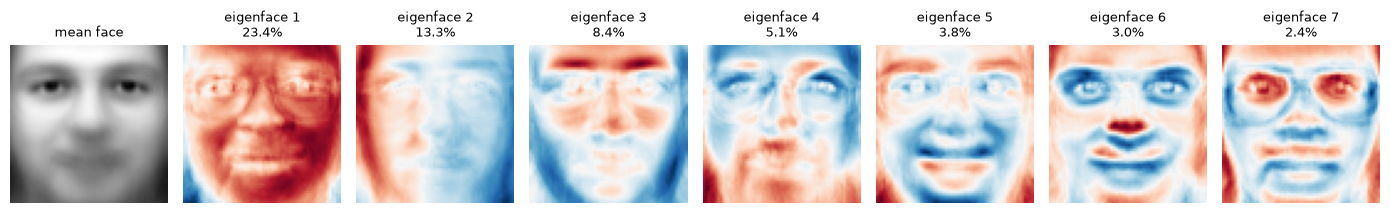

In [16]:
Xfc_tr, Xfc_te, yfc_tr, yfc_te = train_test_split(X_faces, y_faces, test_size=0.25, stratify=y_faces, random_state=SEED)
face_pca = PCA(svd_solver="full").fit(Xfc_tr)
print(f"train {Xfc_tr.shape} | test {Xfc_te.shape} | components available: {face_pca.n_components_} "
      f"(min(n, d) = {min(Xfc_tr.shape)})")

fig, axes = plt.subplots(1, 8, figsize=(14, 2.3))
axes[0].imshow(face_pca.mean_.reshape(64, 64), cmap="gray")
axes[0].set_title("mean face", fontsize=9)
for i, ax in enumerate(axes[1:]):
    ax.imshow(face_pca.components_[i].reshape(64, 64), cmap="RdBu_r")
    ax.set_title(f"eigenface {i + 1}\n{face_pca.explained_variance_ratio_[i]:.1%}", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [17]:
recon_rows = []
Xc_faces_tr, Xc_faces_te = Xfc_tr - face_pca.mean_, Xfc_te - face_pca.mean_
for k in [5, 10, 25, 50, 100, 150, 250]:
    W = face_pca.components_[:k]
    train_sse = ((Xc_faces_tr - Xc_faces_tr @ W.T @ W) ** 2).sum()
    formula_sse = (len(Xfc_tr) - 1) * face_pca.explained_variance_[k:].sum()
    assert np.isclose(train_sse, formula_sse, rtol=1e-6), k
    recon_rows.append({"k": k, "variance kept": face_pca.explained_variance_ratio_[:k].sum(),
                       "train MSE per pixel": train_sse / Xfc_tr.size,
                       "test MSE per pixel": ((Xc_faces_te - Xc_faces_te @ W.T @ W) ** 2).mean(),
                       "compression (4096 / k)": 4096 / k})
recon_table = pd.DataFrame(recon_rows).set_index("k")
print(recon_table.round(5))
print("✅ training error = (n − 1) × sum of discarded eigenvalues, for every k")
print(f"at k=250 the test error is {recon_table.loc[250, 'test MSE per pixel'] / max(recon_table.loc[250, 'train MSE per pixel'], 1e-12):.0f}× "
      f"the training error: late components describe the 300 training photos, not faces in general")

     variance kept  train MSE per pixel  test MSE per pixel  compression (4096 / k)
k                                                                                  
5           0.5411           8.7600e-03              0.0091                819.2000
10          0.6553           6.5800e-03              0.0070                409.6000
25          0.7965           3.8800e-03              0.0047                163.8400
50          0.8797           2.3000e-03              0.0034                 81.9200
100         0.9440           1.0700e-03              0.0026                 40.9600
150         0.9726           5.2000e-04              0.0022                 27.3067
250         0.9961           8.0000e-05              0.0018                 16.3840
✅ training error = (n − 1) × sum of discarded eigenvalues, for every k
at k=250 the test error is 23× the training error: late components describe the 300 training photos, not faces in general


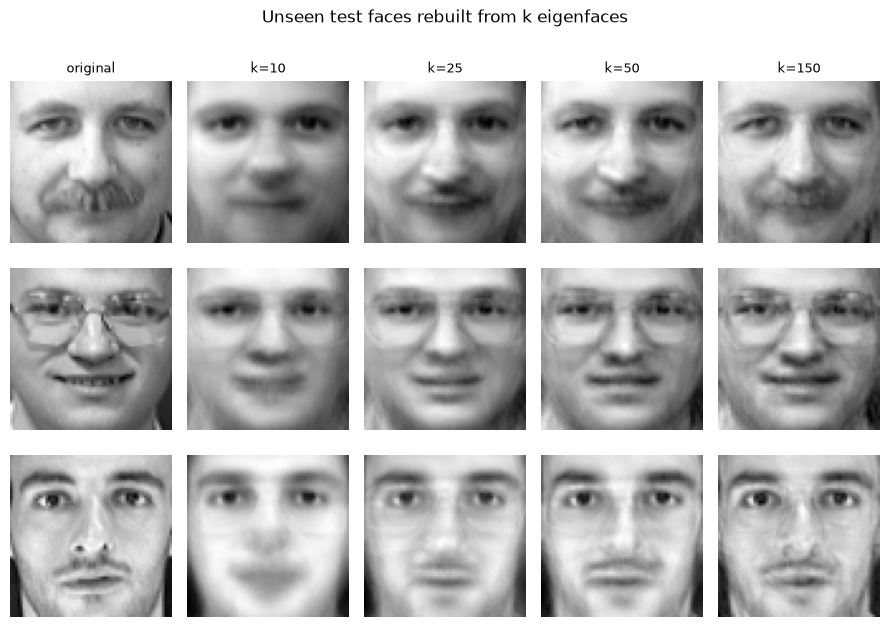

In [18]:
show_ks = [10, 25, 50, 150]
fig, axes = plt.subplots(3, len(show_ks) + 1, figsize=(9, 6.4))
for row, face in enumerate(Xfc_te[:3]):
    axes[row, 0].imshow(face.reshape(64, 64), cmap="gray")
    axes[row, 0].set_title("original" if row == 0 else "", fontsize=9)
    for col, k in enumerate(show_ks, start=1):
        W = face_pca.components_[:k]
        rebuilt = face_pca.mean_ + ((face - face_pca.mean_) @ W.T) @ W
        axes[row, col].imshow(rebuilt.reshape(64, 64), cmap="gray")
        axes[row, col].set_title(f"k={k}" if row == 0 else "", fontsize=9)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Unseen test faces rebuilt from k eigenfaces", y=1.0)
plt.tight_layout()
plt.show()

**Whitening** divides each component's score by its standard deviation, $z_j / \sqrt{\lambda_j}$, so every component has variance 1 and they are uncorrelated (covariance = identity). Why bother? Unwhitened, the first few components have huge variance and dominate every distance; models that use distances or a single shared regularization strength (RBF SVMs, KNN, K-means, L2-penalized models) then barely see the smaller components. The trade-off: whitening also **amplifies** the noisy low-variance components, so combine it with a sensible k.

In [19]:
face_whiten = PCA(n_components=40, whiten=True).fit(Xfc_tr)
Z_white = face_whiten.transform(Xfc_tr)
assert np.allclose(np.cov(Z_white, rowvar=False), np.eye(40), atol=1e-8)
print("✅ whitened training scores have covariance = identity (first 4×4 block):")
print(np.round(np.cov(Z_white, rowvar=False)[:4, :4], 6))
print(f"variance of the raw (unwhitened) scores, first vs 40th component: "
      f"{face_whiten.explained_variance_[0]:.2f} vs {face_whiten.explained_variance_[39]:.4f}")

face_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
whiten_rows = []
for k in [20, 40, 80]:
    for whiten in [False, True]:
        pipe = make_pipeline(PCA(n_components=k, whiten=whiten, random_state=SEED), SVC(kernel="rbf"))
        whiten_rows.append({"k": k, "whiten": whiten, "5-fold accuracy": cross_val_score(pipe, X_faces, y_faces, cv=face_folds).mean()})
whiten_table = pd.DataFrame(whiten_rows).pivot(index="k", columns="whiten", values="5-fold accuracy")
print("\nRBF SVM on the faces (40 people):\n", whiten_table.round(3))
print(f"\nwhitening changed accuracy by {', '.join(f'{(whiten_table.loc[k, True] - whiten_table.loc[k, False]):+.3f} (k={k})' for k in whiten_table.index)}")

✅ whitened training scores have covariance = identity (first 4×4 block):
[[ 1. -0.  0. -0.]
 [-0.  1. -0. -0.]
 [ 0. -0.  1.  0.]
 [-0. -0.  0.  1.]]
variance of the raw (unwhitened) scores, first vs 40th component: 18.37 vs 0.2257



RBF SVM on the faces (40 people):
 whiten  False  True 
k                   
20      0.920  0.950
40      0.928  0.967
80      0.940  0.967

whitening changed accuracy by +0.030 (k=20), +0.040 (k=40), +0.027 (k=80)


### ✍️ Your Turn

A PCA model has mean `mu` and two components (rows of `W`). Reconstruct the point whose scores are `z = [2, 5]`.

In [20]:
mu = np.array([1.0, 2.0, 3.0])
W_toy = np.array([[1.0, 0.0, 0.0],
                  [0.0, 0.6, 0.8]])
z_scores = np.array([2.0, 5.0])
x_rebuilt = None  # TODO: your code here
check("x_rebuilt", x_rebuilt, [3.0, 5.0, 7.0], hint="x̂ = mu + z_scores @ W_toy")

⏳ x_rebuilt: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mu = np.array([1.0, 2.0, 3.0])
W_toy = np.array([[1.0, 0.0, 0.0], [0.0, 0.6, 0.8]])
z_scores = np.array([2.0, 5.0])
x_rebuilt = mu + z_scores @ W_toy
check("x_rebuilt", x_rebuilt, [3.0, 5.0, 7.0])
```

`z @ W = 2·[1, 0, 0] + 5·[0, 0.6, 0.8] = [2, 3, 4]`, plus the mean. This is exactly `PCA.inverse_transform` when `whiten=False`.
</details>

> 💡 **Interview angle:** "What is whitening and when would you use it?" — scale each principal component to unit variance so the features are uncorrelated with equal variance; it helps distance- and penalty-based models (RBF SVM, KNN, K-means, ICA preprocessing) but amplifies noise in small components. Reconstruction error equals the discarded eigenvalues, so the scree plot doubles as a compression-loss curve.

## 7. PCA Inside a Pipeline, Tuned by Cross-Validation 🟡

When PCA feeds a model, the number of components is a **hyperparameter** like any other. Two rules:

1. **PCA goes inside the pipeline.** Fitting PCA on all rows before cross-validation lets the validation rows shape the components (a mild but real leak, Pitfall 1 shows a stronger version).
2. **Tune `n_components` with the model's hyperparameters together**, because they interact (with whitening, more components change what the best `C` is).

On the faces: 4,096 raw pixels vs PCA + RBF SVM, with the grid searched on the same 5 folds. For an honest estimate of the *whole tuning procedure* we also run **nested cross-validation** (an outer loop around the grid search).

In [21]:
face_grid = GridSearchCV(make_pipeline(PCA(whiten=True, random_state=SEED), SVC(kernel="rbf")),
                         param_grid={"pca__n_components": [10, 20, 40, 80, 150], "svc__C": [1, 10, 100]},
                         cv=face_folds)
start = time.perf_counter()
face_grid.fit(X_faces, y_faces)
grid_seconds = time.perf_counter() - start
grid_results = pd.DataFrame(face_grid.cv_results_).pivot(index="param_pca__n_components", columns="param_svc__C", values="mean_test_score")
print(f"grid search: {len(face_grid.cv_results_['params'])} settings × 5 folds in {grid_seconds:.1f}s")
print(grid_results.round(3))
print("best:", face_grid.best_params_, f"| CV accuracy {face_grid.best_score_:.3f}")

outer_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
nested_scores = cross_val_score(face_grid, X_faces, y_faces, cv=outer_folds)
print(f"nested CV accuracy (unbiased estimate of 'grid search + refit'): {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")

grid search: 15 settings × 5 folds in 3.1s
param_svc__C               1      10     100
param_pca__n_components                     
10                       0.873  0.925  0.925
20                       0.950  0.958  0.958
40                       0.967  0.972  0.972
80                       0.967  0.972  0.972
150                      0.965  0.965  0.965
best: {'pca__n_components': 40, 'svc__C': 10} | CV accuracy 0.972


nested CV accuracy (unbiased estimate of 'grid search + refit'): 0.965 ± 0.025


                                        5-fold accuracy  fit ms per fold  predict ms per fold
LogisticRegression on 4,096 raw pixels            0.978         2050.131                0.514
SVC (RBF) on 4,096 raw pixels                     0.943           42.487               28.642
best PCA(40, whiten) + SVC                        0.972           26.006                1.798

PCA + SVC vs raw-pixel logistic regression: accuracy -0.005, fit 79× faster (the grid's best score is slightly optimistic; nested CV said 0.965)


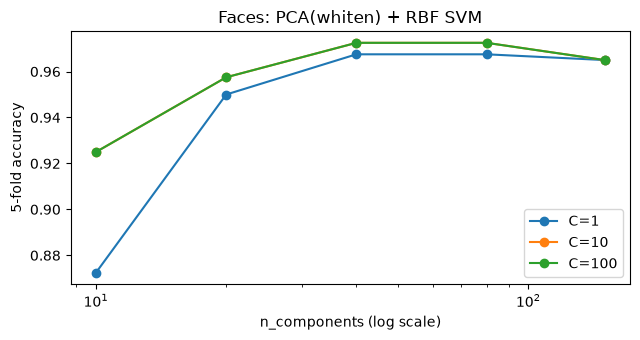

In [22]:
baselines = {
    "LogisticRegression on 4,096 raw pixels": LogisticRegression(max_iter=3000),
    "SVC (RBF) on 4,096 raw pixels": SVC(kernel="rbf"),
    f"best PCA({face_grid.best_params_['pca__n_components']}, whiten) + SVC": face_grid.best_estimator_,
}
face_rows = {}
for name, model in baselines.items():
    res = cross_validate(model, X_faces, y_faces, cv=face_folds)
    face_rows[name] = {"5-fold accuracy": res["test_score"].mean(), "fit ms per fold": res["fit_time"].mean() * 1000,
                       "predict ms per fold": res["score_time"].mean() * 1000}
face_table = pd.DataFrame(face_rows).T
print(face_table.round(3))
lr_name, pca_name = list(baselines)[0], list(baselines)[2]
print(f"\nPCA + SVC vs raw-pixel logistic regression: accuracy {face_table.loc[pca_name, '5-fold accuracy'] - face_table.loc[lr_name, '5-fold accuracy']:+.3f}, "
      f"fit {face_table.loc[lr_name, 'fit ms per fold'] / face_table.loc[pca_name, 'fit ms per fold']:.0f}× faster "
      f"(the grid's best score is slightly optimistic; nested CV said {nested_scores.mean():.3f})")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for C in grid_results.columns:
    ax.plot(grid_results.index, grid_results[C], "o-", label=f"C={C}")
ax.set(xscale="log", xlabel="n_components (log scale)", ylabel="5-fold accuracy", title="Faces: PCA(whiten) + RBF SVM")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "How would you pick the number of PCA components for a classifier?" — put `PCA` in a `Pipeline`, grid-search `pca__n_components` jointly with the model's hyperparameters on CV folds, report nested CV (or a held-out test set) for the final estimate, and look at the fit/predict time too: often a few dozen components match raw features at a fraction of the cost.

## 8. PCA Variants: TruncatedSVD, IncrementalPCA, KernelPCA 🟡

| Variant | Solves | Key difference |
|---|---|---|
| `TruncatedSVD` | huge **sparse** matrices (TF-IDF, one-hot, user–item) | does **not** center the data, so zeros stay zeros and memory stays sparse. On TF-IDF it is called **LSA** (latent semantic analysis) |
| `IncrementalPCA` | data that **doesn't fit in memory** | `partial_fit` on mini-batches; memory depends on the batch size, not n |
| `KernelPCA` | **nonlinear** structure | PCA on a kernel matrix $K_{ij} = k(x_i, x_j)$ (implicitly in a feature space); costs O(n²) memory and O(n³) time |

### 8a. TruncatedSVD for text (LSA)

Five 20-Newsgroups topics, TF-IDF with ~11k words. We compare logistic regression on the sparse TF-IDF with LSA at 50, 100 and 300 dimensions, using the official train/test split.

In [23]:
news_cats = ["comp.graphics", "rec.sport.hockey", "sci.med", "sci.space", "talk.politics.guns"]
news_tr = fetch_20newsgroups(subset="train", categories=news_cats, data_home=DATA_HOME, remove=("headers", "footers", "quotes"))
news_te = fetch_20newsgroups(subset="test", categories=news_cats, data_home=DATA_HOME, remove=("headers", "footers", "quotes"))
tfidf = TfidfVectorizer(min_df=3, stop_words="english", sublinear_tf=True)
T_tr, T_te = tfidf.fit_transform(news_tr.data), tfidf.transform(news_te.data)
print(f"TF-IDF train {T_tr.shape}, {T_tr.nnz / np.prod(T_tr.shape):.2%} non-zero | test {T_te.shape[0]} documents")

lsa_rows = []
for k in [None, 50, 100, 300]:
    if k is None:
        model = LogisticRegression(max_iter=2000)
    else:
        model = make_pipeline(TruncatedSVD(n_components=k, random_state=SEED), Normalizer(), LogisticRegression(max_iter=2000))
    start = time.perf_counter()
    model.fit(T_tr, news_tr.target)
    fit_s = time.perf_counter() - start
    test_bytes = (T_te.data.nbytes + T_te.indices.nbytes + T_te.indptr.nbytes) if k is None else T_te.shape[0] * k * 8
    lsa_rows.append({"features": "sparse TF-IDF" if k is None else f"LSA {k}", "dimensions": T_tr.shape[1] if k is None else k,
                     "test accuracy": model.score(T_te, news_te.target), "fit seconds": fit_s, "test feature KB": test_bytes / 1e3})
lsa_table = pd.DataFrame(lsa_rows).set_index("features")
print(lsa_table.round(3))
best_lsa = lsa_table.iloc[1:]["test accuracy"].idxmax()
print(f"\n{best_lsa} reaches {lsa_table.loc[best_lsa, 'test accuracy']:.3f} vs {lsa_table.iloc[0]['test accuracy']:.3f} on the full sparse "
      f"TF-IDF, with {lsa_table.iloc[0]['dimensions'] / lsa_table.loc[best_lsa, 'dimensions']:.0f}× fewer dimensions")
print(f"memory: dense {best_lsa} features take {lsa_table.loc[best_lsa, 'test feature KB']:.0f} KB vs {lsa_table.iloc[0]['test feature KB']:.0f} KB "
      f"for the sparse TF-IDF → fewer dimensions is not automatically less memory when the original matrix is very sparse")

TF-IDF train (2917, 11581), 0.51% non-zero | test 1942 documents


               dimensions  test accuracy  fit seconds  test feature KB
features                                                              
sparse TF-IDF       11581          0.869        0.103         1275.548
LSA 50                 50          0.859        0.068          776.800
LSA 100               100          0.860        0.136         1553.600
LSA 300               300          0.864        0.489         4660.800

LSA 300 reaches 0.864 vs 0.869 on the full sparse TF-IDF, with 39× fewer dimensions
memory: dense LSA 300 features take 4661 KB vs 1276 KB for the sparse TF-IDF → fewer dimensions is not automatically less memory when the original matrix is very sparse


In [24]:
lsa = TruncatedSVD(n_components=100, random_state=SEED).fit(T_tr)
terms = tfidf.get_feature_names_out()
for j in range(4):
    top = np.argsort(lsa.components_[j])[::-1][:8]
    print(f"component {j}: {', '.join(terms[top])}")
doc_mean_direction = np.asarray(T_tr.mean(axis=0)).ravel()
cos_with_mean = abs(lsa.components_[0] @ doc_mean_direction) / np.linalg.norm(doc_mean_direction)
print(f"\n|cos| between component 0 and the average document: {cos_with_mean:.2f} → without centering, "
      f"the first component {'mostly points at the mean' if cos_with_mean > 0.5 else 'is not the mean direction here'}")

start = time.perf_counter()
sparse_pca = PCA(n_components=100, svd_solver="arpack").fit(T_tr)
sparse_pca_s = time.perf_counter() - start
start = time.perf_counter()
TruncatedSVD(n_components=100, algorithm="arpack").fit(T_tr)
tsvd_arpack_s = time.perf_counter() - start
print(f"\nPCA(svd_solver='arpack') also accepts sparse input and centers implicitly: {sparse_pca_s:.2f}s vs TruncatedSVD(arpack) {tsvd_arpack_s:.2f}s")

component 0: don, like, know, just, think, people, time, good
component 1: geb, shameful, dsl, n3jxp, chastity, cadre, skepticism, intellect
component 2: game, team, hockey, play, games, season, players, nhl
component 3: thanks, graphics, files, mail, advance, game, file, program

|cos| between component 0 and the average document: 0.99 → without centering, the first component mostly points at the mean



PCA(svd_solver='arpack') also accepts sparse input and centers implicitly: 0.16s vs TruncatedSVD(arpack) 0.17s


Component 0 of an uncentered SVD is roughly "the average document"; later components pick up topics (hockey words, graphics words). Component 1 is a real-data quirk worth noticing: its top words come from one prolific poster's repeated email signature (a quote about skepticism plus an address) that `remove=("headers", "footers", "quotes")` didn't strip. LSA finds whatever co-occurs strongly, boilerplate included. Modern scikit-learn's `PCA` can take sparse input with the `"arpack"` or `"covariance_eigh"` solvers by centering *implicitly*; `TruncatedSVD` remains the standard for LSA and very large sparse matrices.

### 8b. IncrementalPCA for data that doesn't fit in memory

We feed the 60,000 Fashion-MNIST training images in batches of 5,000, as if they were read from disk one chunk at a time, and compare with regular PCA on the whole matrix.

In [25]:
X_train60 = X_fashion_all[:60_000]
batch_size = 5_000
start = time.perf_counter()
ipca = IncrementalPCA(n_components=50, batch_size=batch_size)
for first in range(0, len(X_train60), batch_size):
    ipca.partial_fit(X_train60[first:first + batch_size])        # in real life: the next chunk from disk
ipca_s = time.perf_counter() - start
start = time.perf_counter()
full_pca = PCA(n_components=50, random_state=SEED).fit(X_train60)
full_s = time.perf_counter() - start

cosines = np.abs((ipca.components_ * full_pca.components_).sum(axis=1))
print(f"IncrementalPCA: {ipca_s:.1f}s, variance kept {ipca.explained_variance_ratio_.sum():.4f}, "
      f"largest batch in memory {X_train60[:batch_size].nbytes / 1e6:.0f} MB")
print(f"PCA           : {full_s:.1f}s, variance kept {full_pca.explained_variance_ratio_.sum():.4f}, "
      f"whole matrix in memory {X_train60.nbytes / 1e6:.0f} MB")
print(f"|cos| between matching components: first 10 min {cosines[:10].min():.6f}, all 50 min {cosines.min():.4f}")
del X_train60
_ = gc.collect()

IncrementalPCA: 2.2s, variance kept 0.8625, largest batch in memory 16 MB
PCA           : 0.1s, variance kept 0.8627, whole matrix in memory 188 MB
|cos| between matching components: first 10 min 1.000000, all 50 min 0.6965


The leading components match essentially perfectly; the last few can drift slightly because nearby eigenvalues are hard to separate from mini-batch updates. That's the usual trade: bounded memory for a small approximation in the tail.

### 8c. KernelPCA for nonlinear structure

Two concentric rings are the textbook case where no straight axis can separate the classes. This is a **controlled synthetic example** (`make_circles`), used because the geometry is known exactly.

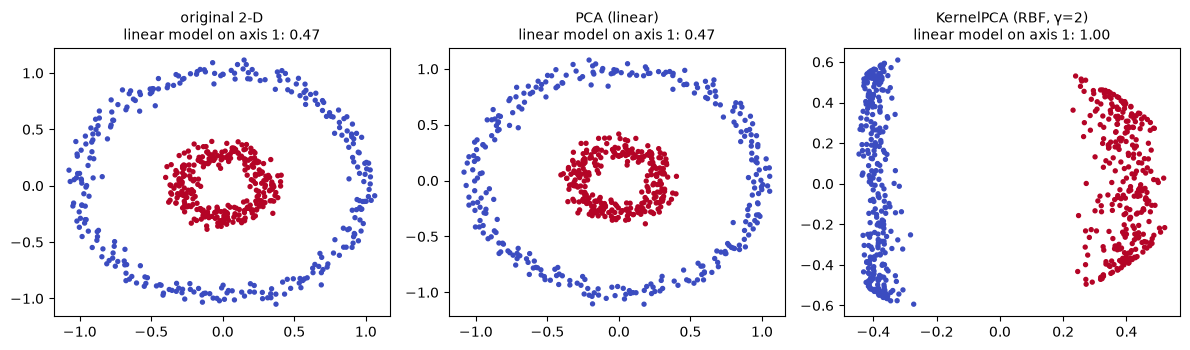

           fit seconds  kernel matrix MB
n samples                               
400              0.006              1.28
800              0.021              5.12
1600             0.120             20.48
4× the rows → 16× the kernel memory and 18.7× the time


In [26]:
X_rings, y_rings = make_circles(n_samples=600, factor=0.3, noise=0.05, random_state=SEED)
ring_embeddings = {"original 2-D": X_rings,
                   "PCA (linear)": PCA(n_components=2).fit_transform(X_rings),
                   "KernelPCA (RBF, γ=2)": KernelPCA(n_components=2, kernel="rbf", gamma=2).fit_transform(X_rings)}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, E) in zip(axes, ring_embeddings.items()):
    acc = cross_val_score(LogisticRegression(), E[:, :1], y_rings, cv=5).mean()     # a threshold on the FIRST axis only
    ax.scatter(*E.T, c=y_rings, cmap="coolwarm", s=8)
    ax.set_title(f"{name}\nlinear model on axis 1: {acc:.2f}", fontsize=10)
plt.tight_layout()
plt.show()

kpca_rows = []
for n in [400, 800, 1600]:
    start = time.perf_counter()
    KernelPCA(n_components=20, kernel="rbf").fit(X_digits[:n])
    kpca_rows.append({"n samples": n, "fit seconds": time.perf_counter() - start, "kernel matrix MB": n * n * 8 / 1e6})
kpca_table = pd.DataFrame(kpca_rows).set_index("n samples")
print(kpca_table.round(3))
print(f"4× the rows → {kpca_table['kernel matrix MB'].iloc[-1] / kpca_table['kernel matrix MB'].iloc[0]:.0f}× the kernel memory "
      f"and {kpca_table['fit seconds'].iloc[-1] / kpca_table['fit seconds'].iloc[0]:.1f}× the time")

### ✍️ Your Turn

How many **gigabytes** would the float64 kernel matrix of `KernelPCA` need for `n = 100,000` rows? (1 GB = 10⁹ bytes.)

In [27]:
n_rows = 100_000
kernel_gb = None  # TODO: your code here
check("kernel_gb", kernel_gb, 80.0, hint="An n × n matrix of 8-byte floats: n * n * 8 / 1e9")

⏳ kernel_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_rows = 100_000
kernel_gb = n_rows * n_rows * 8 / 1e9
check("kernel_gb", kernel_gb, 80.0)
```

80 GB, which is why exact kernel methods stop around tens of thousands of rows. Approximations (`Nystroem`, random Fourier features) or UMAP take over beyond that.
</details>

> 💡 **Interview angle:** "PCA on a 1M × 100k sparse TF-IDF matrix?" — use `TruncatedSVD` (no centering, keeps sparsity; LSA) or randomized methods; for data that doesn't fit in RAM use `IncrementalPCA` with `partial_fit`; for nonlinear structure consider `KernelPCA` on a sample (O(n²) memory) or UMAP.

## 9. Assumptions and When They Break 🟡

PCA quietly assumes:

1. **Linearity:** the important structure lies along straight directions (8c broke this).
2. **Large variance = important.** PCA never looks at labels, so the most spread-out direction may have nothing to do with the target.
3. **Features are on comparable scales** (Section 5 broke this).
4. **No extreme outliers:** variance squares distances, so one bad row can rotate the components.

**Experiment A — variance is not relevance.** PCA (unsupervised) vs **LDA** (Linear Discriminant Analysis, which picks directions that *separate the classes*), both reducing to 2 dimensions, same folds.

In [28]:
lda_rows = []
for data_name, X, y in [("wine (13 features)", X_wine.to_numpy(), y_wine), ("digits (64 pixels)", X_digits, y_digits)]:
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    for method_name, reducer in [("PCA → 2", PCA(n_components=2)), ("LDA → 2", LinearDiscriminantAnalysis(n_components=2))]:
        pipe = make_pipeline(StandardScaler(), reducer, KNeighborsClassifier())
        lda_rows.append({"data": data_name, "reducer": method_name, "5-fold KNN accuracy": cross_val_score(pipe, X, y, cv=folds).mean()})
lda_table = pd.DataFrame(lda_rows).pivot(index="data", columns="reducer", values="5-fold KNN accuracy")
print(lda_table.round(3))
for data_name, row in lda_table.iterrows():
    print(f"{data_name}: LDA beats PCA by {row['LDA → 2'] - row['PCA → 2']:+.3f} with the same 2 dimensions")

reducer             LDA → 2  PCA → 2
data                                
digits (64 pixels)    0.658    0.529
wine (13 features)    0.989    0.967
digits (64 pixels): LDA beats PCA by +0.129 with the same 2 dimensions
wine (13 features): LDA beats PCA by +0.022 with the same 2 dimensions


**Experiment B — one outlier.** We corrupt **one** of 178 standardized wine rows with a controlled data-entry error (magnesium set to 40 standard deviations, like a misplaced decimal point) and measure how far the first component rotates.

In [29]:
Z_wine = StandardScaler().fit_transform(X_wine)
clean = PCA(n_components=2).fit(Z_wine)
Z_corrupt = Z_wine.copy()
magnesium = list(X_wine.columns).index("magnesium")
Z_corrupt[0, magnesium] = 40.0
dirty = PCA(n_components=2).fit(Z_corrupt)
rotation = np.degrees(np.arccos(np.clip(abs(clean.components_[0] @ dirty.components_[0]), 0, 1)))
print(f"PC1 rotated by {rotation:.1f}° because of 1 bad row out of {len(Z_wine)}")
print(f"magnesium's weight in PC1: clean {clean.components_[0, magnesium]:+.2f} → corrupted {dirty.components_[0, magnesium]:+.2f}")
print(f"variance explained by PC1: clean {clean.explained_variance_ratio_[0]:.1%} → corrupted {dirty.explained_variance_ratio_[0]:.1%}")

PC1 rotated by 70.0° because of 1 bad row out of 178
magnesium's weight in PC1: clean +0.14 → corrupted +0.97
variance explained by PC1: clean 36.2% → corrupted 46.7%


A single row turned PC1 into a "magnesium outlier detector". Fixes: clean or clip outliers first, use robust scaling, or robust covariance estimates (e.g. `MinCovDet`, which the next notebook uses for anomaly detection). The flip side is useful: **large reconstruction error from PCA is itself an anomaly score** ([Anomaly Detection](15_Anomaly_Detection.ipynb)).

> 💡 **Interview angle:** "What are PCA's assumptions?" — linear structure, variance = importance (it ignores labels; LDA or supervised methods use them), comparable feature scales, and no extreme outliers (squared distances let one row rotate the components). Show you know the remedies: kernel/UMAP for nonlinearity, LDA or CV-tuned pipelines, standardization, robust preprocessing.

## 10. t-SNE: Perplexity, Crowding and KL Divergence 🟡

**t-SNE** (t-distributed Stochastic Neighbor Embedding) draws a 2-D map where points that were **neighbours** in high dimensions stay neighbours. The recipe in plain words:

1. **High-dimensional similarities.** For each point $i$, put a Gaussian bump on it and turn distances into probabilities "$j$ is my neighbour": $p_{j\mid i} \propto \exp(-\lVert x_i - x_j\rVert^2 / 2\sigma_i^2)$. Each point gets its own width $\sigma_i$, chosen so that the **perplexity** $2^{H(P_i)}$ (with $H$ the entropy in bits) equals the value you set. **Perplexity ≈ the effective number of neighbours each point pays attention to.** Then symmetrize: $p_{ij} = (p_{j\mid i} + p_{i\mid j}) / 2n$.
2. **Low-dimensional similarities** use a **Student-t distribution with one degree of freedom** (heavy tails): $q_{ij} \propto (1 + \lVert y_i - y_j\rVert^2)^{-1}$.
3. **Move the 2-D points** by gradient descent to make $Q$ match $P$, minimizing the **KL divergence**
   $$\mathrm{KL}(P\,\Vert\,Q) = \sum_{i \ne j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**KL in plain words:** a big penalty when two true neighbours ($p$ large) are drawn far apart ($q$ small); almost no penalty when two far-apart points are drawn close. So t-SNE works hard on **local** structure and doesn't care about **global** layout.

**The crowding problem** explains the heavy tails. In high dimensions a point can have many equidistant neighbours; in 2-D there isn't enough room near it. Squeeze the neighbours in, and moderately distant points get pushed into the same small area. The Student-t's heavy tails let moderately distant points sit **much farther away** in 2-D, which opens clean gaps between clusters.

**Practical extras:** early exaggeration (multiply $P$ by 12 for the first 250 iterations so clusters form), Barnes–Hut approximation (O(n log n) per iteration), and `init="pca"` (the default, more stable than random).

A quick number behind crowding: the share of a $d$-dimensional ball's volume that lies within **half** its radius is $0.5^d$.

2     2.5000e-01
3     1.2500e-01
10    9.7656e-04
64    5.4210e-20


            seconds  final KL  trustworthiness k=10  trustworthiness k=100  5-NN accuracy in 2-D
perplexity                                                                                      
2            1.9342    0.9109                0.9823                 0.8821                0.9861
10           1.9194    0.9073                0.9926                 0.9503                0.9900
30           2.4872    0.7539                0.9926                 0.9631                0.9889
100          2.6702    0.5939                0.9905                 0.9681                0.9811

best local neighbourhoods (k=10): perplexity 10 | best larger neighbourhoods (k=100): perplexity 100
Note: KL values are not comparable across perplexities, because P itself changes with perplexity.


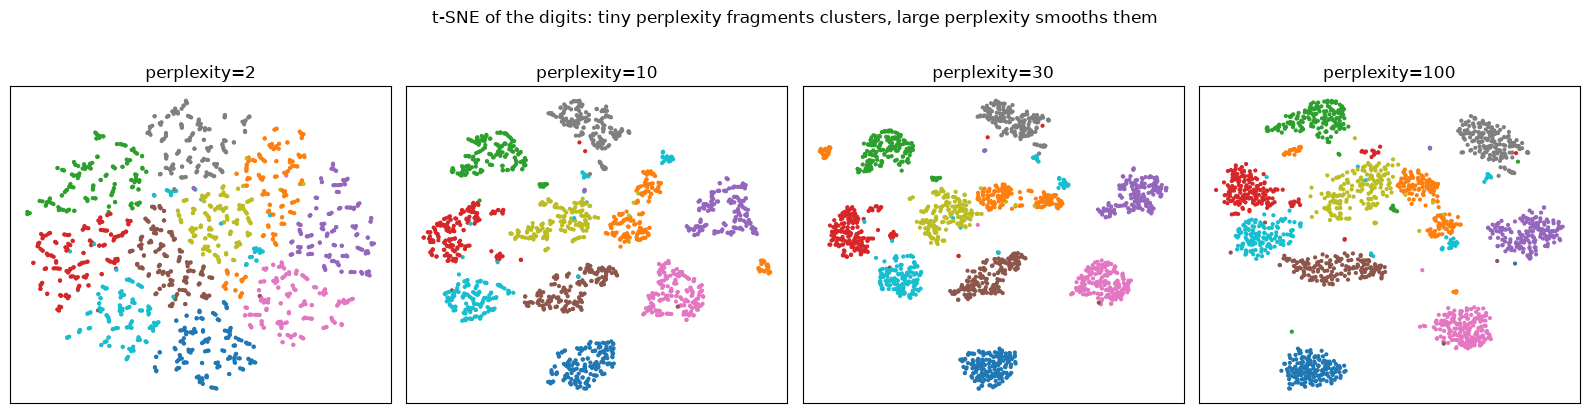

In [30]:
print(pd.Series({d: 0.5 ** d for d in [2, 3, 10, 64]}, name="share of volume inside half the radius").to_string())

digit_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def knn_accuracy(E, y, folds):
    """5-NN cross-validated accuracy inside an embedding: how well classes stay grouped."""
    return cross_val_score(KNeighborsClassifier(n_neighbors=5), E, y, cv=folds).mean()


tsne_rows, tsne_maps = [], {}
for perplexity in [2, 10, 30, 100]:
    start = time.perf_counter()
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED)
    E = tsne.fit_transform(X_digits)
    seconds = time.perf_counter() - start
    tsne_maps[perplexity] = E
    tsne_rows.append({"perplexity": perplexity, "seconds": seconds, "final KL": tsne.kl_divergence_,
                      "trustworthiness k=10": trustworthiness(X_digits, E, n_neighbors=10),
                      "trustworthiness k=100": trustworthiness(X_digits, E, n_neighbors=100),
                      "5-NN accuracy in 2-D": knn_accuracy(E, y_digits, digit_folds)})
tsne_table = pd.DataFrame(tsne_rows).set_index("perplexity")
print(tsne_table.round(4))
print(f"\nbest local neighbourhoods (k=10): perplexity {tsne_table['trustworthiness k=10'].idxmax()} | "
      f"best larger neighbourhoods (k=100): perplexity {tsne_table['trustworthiness k=100'].idxmax()}")
print("Note: KL values are not comparable across perplexities, because P itself changes with perplexity.")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (perplexity, E) in zip(axes, tsne_maps.items()):
    ax.scatter(*E.T, c=y_digits, cmap="tab10", s=4)
    ax.set(title=f"perplexity={perplexity}", xticks=[], yticks=[])
plt.suptitle("t-SNE of the digits: tiny perplexity fragments clusters, large perplexity smooths them", y=1.02)
plt.tight_layout()
plt.show()

**Trustworthiness** (from 0 to 1) asks: *are the k nearest neighbours in the embedding really near in the original space?* It penalizes "intruders", points that appear close in 2-D but were far away. We use it again in Section 14.

### ✍️ Your Turn

One point's neighbour probabilities are `p = [0.5, 0.25, 0.25]`. Compute its **perplexity** $2^{H}$ with the entropy $H = -\sum p \log_2 p$ in bits.

In [31]:
p_neighbours = np.array([0.5, 0.25, 0.25])
perplexity_value = None  # TODO: your code here
check("perplexity_value", perplexity_value, 2.8284271, hint="H = -(p * np.log2(p)).sum(); perplexity = 2 ** H")

⏳ perplexity_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_neighbours = np.array([0.5, 0.25, 0.25])
entropy_bits = -(p_neighbours * np.log2(p_neighbours)).sum()
perplexity_value = 2 ** entropy_bits
check("perplexity_value", perplexity_value, 2.8284271)
```

H = 1.5 bits, so the perplexity is 2^1.5 ≈ 2.83 "effective neighbours": between 2 and 3, as the probabilities suggest. A uniform distribution over k neighbours has perplexity exactly k.
</details>

> 💡 **Interview angle:** "Explain t-SNE's perplexity and why it uses a Student-t." — perplexity sets each point's Gaussian width so it effectively attends to about that many neighbours (typical 5–50); the heavy-tailed Student-t in 2-D solves the crowding problem by letting moderately distant points spread out; the KL objective punishes separating true neighbours far more than merging distant points, so local structure is kept and global structure is not.

## 11. What NOT to Read From a t-SNE Plot 🔴

From Wattenberg, Viégas & Johnson's *How to Use t-SNE Effectively* (Distill, 2016), each checked here with an experiment:

1. **Cluster sizes mean nothing.** t-SNE expands dense clusters and contracts sparse ones.
2. **Distances between clusters may mean nothing.**
3. **Perplexity and initialization change the picture.** With the default `init="pca"` scikit-learn's t-SNE is close to deterministic, but random initialization or another perplexity can move clusters around. Run several before believing a shape.
4. **There is no `transform`.** You can't place new points on an existing map.

**Experiment A — sizes (controlled).** Two synthetic Gaussian blobs in 50 dimensions, one with standard deviation 1 and one with standard deviation **10** (a controlled example: we know the true sizes).

size ratio large/small: true 10.1× | in the t-SNE map 1.00× → t-SNE made the clusters look about the same size


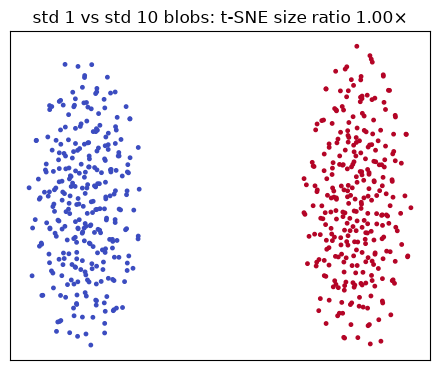

In [32]:
blob_small = rng.normal(0, 1, size=(300, 50))
blob_large = rng.normal(0, 10, size=(300, 50))
blob_large[:, 0] += 400                                         # far apart, no overlap
blobs, blob_id = np.vstack([blob_small, blob_large]), np.repeat([0, 1], 300)
E_blobs = TSNE(perplexity=30, random_state=SEED).fit_transform(blobs)


def spread(P, labels, c):
    """Median distance of a cluster's points to their own centroid."""
    pts = P[labels == c]
    return np.median(np.linalg.norm(pts - pts.mean(axis=0), axis=1))


true_ratio = spread(blobs, blob_id, 1) / spread(blobs, blob_id, 0)
tsne_ratio = spread(E_blobs, blob_id, 1) / spread(E_blobs, blob_id, 0)
print(f"size ratio large/small: true {true_ratio:.1f}× | in the t-SNE map {tsne_ratio:.2f}× "
      f"→ {'t-SNE made the clusters look about the same size' if tsne_ratio < true_ratio / 3 else 't-SNE kept the size difference'}")

fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.scatter(*E_blobs.T, c=blob_id, cmap="coolwarm", s=6)
ax.set(title=f"std 1 vs std 10 blobs: t-SNE size ratio {tsne_ratio:.2f}×", xticks=[], yticks=[])
plt.tight_layout()
plt.show()

**Experiment B — real digits: sizes, between-cluster distances and seeds.** For each embedding we compute two rank correlations (Spearman, from −1 to 1) with the original 64-D space: one for the 10 class **spreads** (sizes) and one for the 45 distances **between class centroids**. PCA is included as a reference, since a linear projection keeps global geometry better.

                                             Spearman: class sizes  Spearman: between-cluster distances  5-NN accuracy
PCA 2-D (reference)                                          0.685                                0.815          0.632
t-SNE perplexity 30, init='pca', seed 42                     0.467                                0.819          0.989
t-SNE perplexity 30, init='pca', seed 7                      0.467                                0.819          0.989
t-SNE perplexity 30, init='random', seed 7                   0.576                                0.680          0.988
t-SNE perplexity 30, init='random', seed 11                  0.636                                0.641          0.989
t-SNE perplexity 100, init='pca', seed 42                    0.588                                0.835          0.981

init='pca' with seeds 42 and 7 gives identical maps: True
across t-SNE settings, the between-cluster distance correlation ranges from 0.64 to 0.83, and the size corre

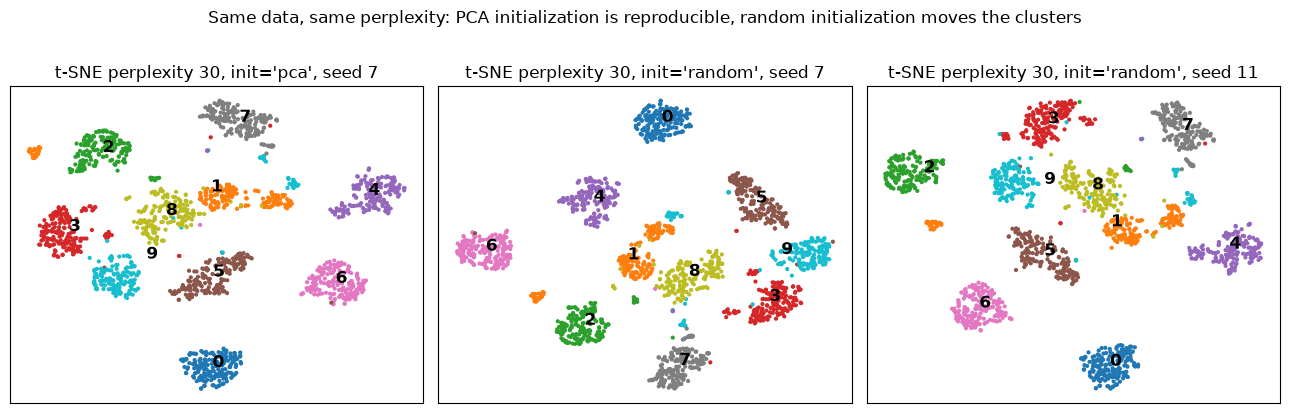

In [33]:
def centroid_distances(P, labels):
    C = np.vstack([P[labels == c].mean(axis=0) for c in np.unique(labels)])
    return pairwise_distances(C)[np.triu_indices(len(C), k=1)]


def class_spreads(P, labels):
    return np.array([spread(P, labels, c) for c in np.unique(labels)])


raw_cd, raw_spread = centroid_distances(X_digits, y_digits), class_spreads(X_digits, y_digits)
geometry_maps = {
    "PCA 2-D (reference)": PCA(n_components=2).fit_transform(X_digits),
    "t-SNE perplexity 30, init='pca', seed 42": tsne_maps[30],
    "t-SNE perplexity 30, init='pca', seed 7": TSNE(random_state=7).fit_transform(X_digits),
    "t-SNE perplexity 30, init='random', seed 7": TSNE(init="random", random_state=7).fit_transform(X_digits),
    "t-SNE perplexity 30, init='random', seed 11": TSNE(init="random", random_state=11).fit_transform(X_digits),
    "t-SNE perplexity 100, init='pca', seed 42": tsne_maps[100],
}
geometry_rows = {name: {"Spearman: class sizes": spearmanr(raw_spread, class_spreads(E, y_digits)).statistic,
                        "Spearman: between-cluster distances": spearmanr(raw_cd, centroid_distances(E, y_digits)).statistic,
                        "5-NN accuracy": knn_accuracy(E, y_digits, digit_folds)}
                 for name, E in geometry_maps.items()}
geometry_table = pd.DataFrame(geometry_rows).T
print(geometry_table.round(3))
tsne_only = geometry_table.drop(index="PCA 2-D (reference)")
same_with_pca_init = np.allclose(geometry_maps["t-SNE perplexity 30, init='pca', seed 42"], geometry_maps["t-SNE perplexity 30, init='pca', seed 7"])
print(f"\ninit='pca' with seeds 42 and 7 gives identical maps: {same_with_pca_init}")
print(f"across t-SNE settings, the between-cluster distance correlation ranges from "
      f"{tsne_only['Spearman: between-cluster distances'].min():.2f} to {tsne_only['Spearman: between-cluster distances'].max():.2f}, "
      f"and the size correlation from {tsne_only['Spearman: class sizes'].min():.2f} to {tsne_only['Spearman: class sizes'].max():.2f}, "
      f"while 5-NN accuracy stays between {tsne_only['5-NN accuracy'].min():.3f} and {tsne_only['5-NN accuracy'].max():.3f}.")
print("→ local grouping is stable; the global layout and sizes depend on initialization and perplexity.")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, name in zip(axes, list(geometry_maps)[2:5]):
    E = geometry_maps[name]
    ax.scatter(*E.T, c=y_digits, cmap="tab10", s=4)
    for c in range(10):
        ax.annotate(str(c), E[y_digits == c].mean(axis=0), fontsize=12, weight="bold")
    ax.set(title=name, xticks=[], yticks=[])
plt.suptitle("Same data, same perplexity: PCA initialization is reproducible, random initialization moves the clusters", y=1.02)
plt.tight_layout()
plt.show()

**Experiment C — no `transform`.**

In [34]:
try:
    TSNE(random_state=SEED).fit(X_digits[:500]).transform(X_digits[500:510])
except AttributeError as err:
    print("❌ AttributeError:", err)
print("✅ options: refit t-SNE on old + new points, use PCA or UMAP (both have .transform), "
      "or openTSNE, which can add points to an existing embedding")

❌ AttributeError: 'TSNE' object has no attribute 'transform'
✅ options: refit t-SNE on old + new points, use PCA or UMAP (both have .transform), or openTSNE, which can add points to an existing embedding


### ✍️ Your Turn

The distances between 5 cluster pairs are `[1, 2, 3, 4, 5]` in the original space and `[2, 1, 4, 3, 5]` in a t-SNE map. Compute the **Spearman rank correlation** with `scipy.stats.spearmanr`.

In [35]:
original_d = [1, 2, 3, 4, 5]
tsne_d = [2, 1, 4, 3, 5]
rank_corr = None  # TODO: your code here
check("rank_corr", rank_corr, 0.8, hint="spearmanr(original_d, tsne_d).statistic")

⏳ rank_corr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
original_d = [1, 2, 3, 4, 5]
tsne_d = [2, 1, 4, 3, 5]
rank_corr = spearmanr(original_d, tsne_d).statistic
check("rank_corr", rank_corr, 0.8)
```

With no ties, $\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$; the rank differences are `[1, 1, 1, 1, 0]`, so $\rho = 1 - 24/120 = 0.8$.
</details>

> 💡 **Interview angle:** "A t-SNE plot shows two customer clusters far apart, and one looks much bigger. What can you conclude?" — only that each cluster's points are similar to each other. Sizes and gaps are not reliable (t-SNE equalizes densities; global distances vary with initialization and perplexity). Check with several seeds/perplexities, and measure in the original space: centroid distances, cluster spreads, or a classifier.

## 12. UMAP: Neighbours, min_dist, transform and Supervision 🟡

**UMAP** (Uniform Manifold Approximation and Projection) also keeps neighbours close, but builds its map from a **graph**:

1. Find each point's `n_neighbors` nearest neighbours (fast approximate search with NN-descent).
2. Turn distances into edge weights. Each point measures distance *relative to its own nearest neighbour* (so dense and sparse regions are treated alike), then the directed weights are combined with a **fuzzy union** $w_{ij} = a + b - ab$.
3. In low dimensions, similarity is $1/(1 + a\,d^{2b})$, where `a` and `b` are fitted from `min_dist`.
4. Optimize a **cross-entropy** with stochastic gradient descent: pull graph neighbours together (attraction) and push randomly sampled non-neighbours apart (**negative sampling**, repulsion). Initialization is spectral (from the graph's Laplacian eigenvectors).

| Parameter | Controls | Small value | Large value |
|---|---|---|---|
| `n_neighbors` | how big a neighbourhood defines "local" | fine detail, fragmented clusters | smoother, more global structure |
| `min_dist` | how tightly points may pack in the map | tight, clumpy clusters (good before clustering) | evenly spread points (good for seeing within-cluster structure) |
| `n_components` | output dimensions | 2 for plots | 5–50 before clustering or KNN |
| `metric` | distance in the input space | `"euclidean"`, `"cosine"` for embeddings, `"hamming"`… | |

First, a tiny warm-up run: UMAP compiles its numba code on first use, and that one-time cost shouldn't count in the timings.

one-time numba compilation + tiny fit: 4.4s


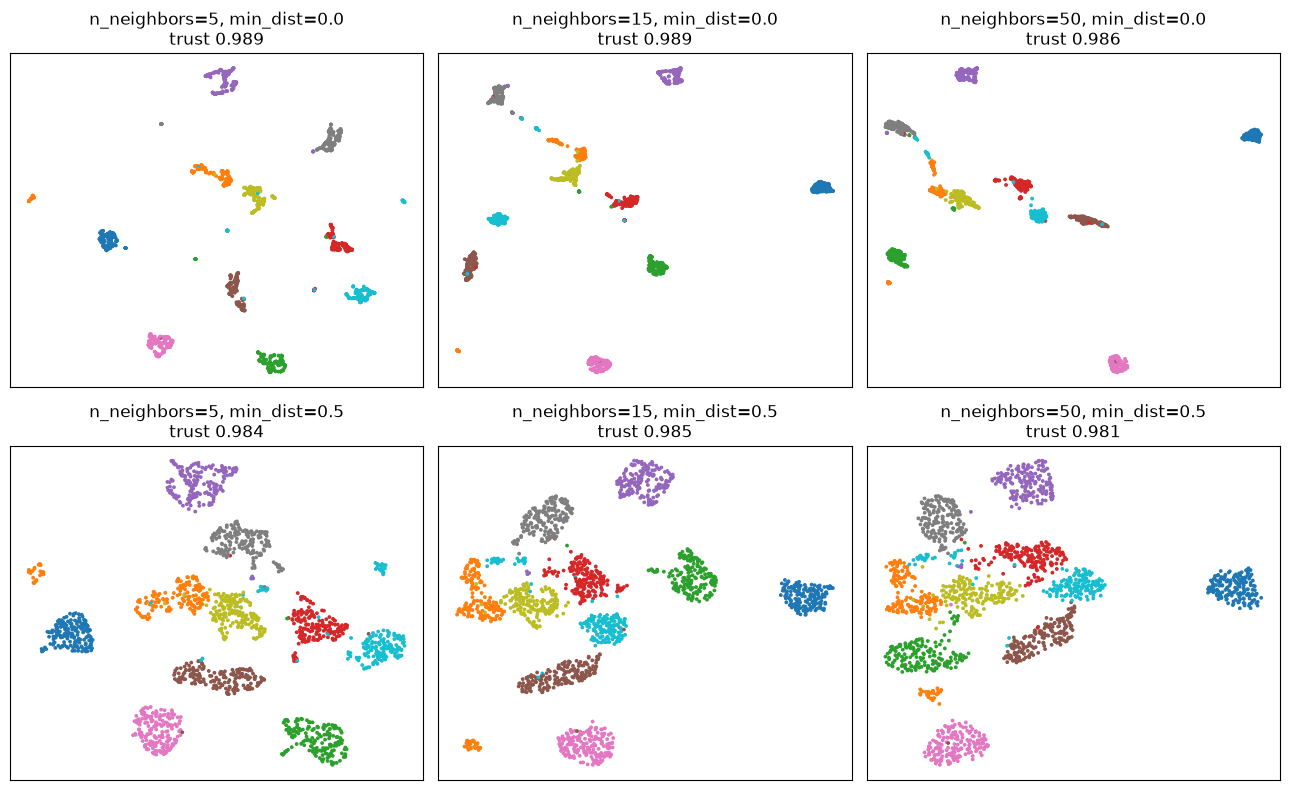

                      seconds  trustworthiness k=10  Spearman: between-cluster distances
n_neighbors min_dist                                                                    
5           0.0         1.557                 0.989                                0.509
15          0.0         2.028                 0.989                                0.627
50          0.0         2.601                 0.986                                0.681
5           0.5         1.525                 0.984                                0.508
15          0.5         2.022                 0.985                                0.489
50          0.5         2.527                 0.981                                0.650

average between-cluster distance correlation by n_neighbors: {5: 0.51, 15: 0.56, 50: 0.67} → larger neighbourhoods kept more global structure here


In [36]:
start = time.perf_counter()
_warm = umap.UMAP(n_neighbors=5, n_epochs=30, random_state=SEED, n_jobs=1).fit(X_digits[:300])
_warm.transform(X_digits[300:320])
print(f"one-time numba compilation + tiny fit: {time.perf_counter() - start:.1f}s")

umap_rows = []
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for r, min_dist in enumerate([0.0, 0.5]):
    for c, n_neighbors in enumerate([5, 15, 50]):
        start = time.perf_counter()
        E = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=SEED, n_jobs=1).fit_transform(X_digits)
        seconds = time.perf_counter() - start
        row = {"n_neighbors": n_neighbors, "min_dist": min_dist, "seconds": seconds,
               "trustworthiness k=10": trustworthiness(X_digits, E, n_neighbors=10),
               "Spearman: between-cluster distances": spearmanr(raw_cd, centroid_distances(E, y_digits)).statistic}
        umap_rows.append(row)
        axes[r, c].scatter(*E.T, c=y_digits, cmap="tab10", s=3)
        axes[r, c].set(title=f"n_neighbors={n_neighbors}, min_dist={min_dist}\ntrust {row['trustworthiness k=10']:.3f}",
                       xticks=[], yticks=[])
plt.tight_layout()
plt.show()
umap_table = pd.DataFrame(umap_rows).set_index(["n_neighbors", "min_dist"])
print(umap_table.round(3))
by_nn = umap_table.groupby(level="n_neighbors")["Spearman: between-cluster distances"].mean()
print(f"\naverage between-cluster distance correlation by n_neighbors: {by_nn.round(2).to_dict()} → "
      f"{'larger neighbourhoods kept more global structure here' if by_nn.iloc[-1] > by_nn.iloc[0] else 'no clear global gain from larger neighbourhoods here'}")

**`transform` and supervised UMAP.** UMAP learns a reusable mapping: fit on training images, then place **unseen** test images with `transform`. Passing labels, `fit(X, y)`, makes it **supervised**: the graph is adjusted so same-class points attract. (Label `-1` marks unlabelled rows for semi-supervised use.) We score each embedding by a KNN trained on the training embedding and tested on the transformed test points.

                                     test accuracy  dimensions  transform ms (541 images)
raw 64-D pixels (no reduction)               0.987        64.0                        NaN
PCA 2-D                                      0.624         2.0                        NaN
UMAP 2-D (unsupervised)                      0.981         2.0                    408.038
UMAP 2-D (supervised, y_train only)          0.972         2.0                    411.049

supervised vs unsupervised UMAP on unseen digits: 0.972 vs 0.981 (-0.009)
→ labels shape the TRAINING map; they don't guarantee better placement of unseen points


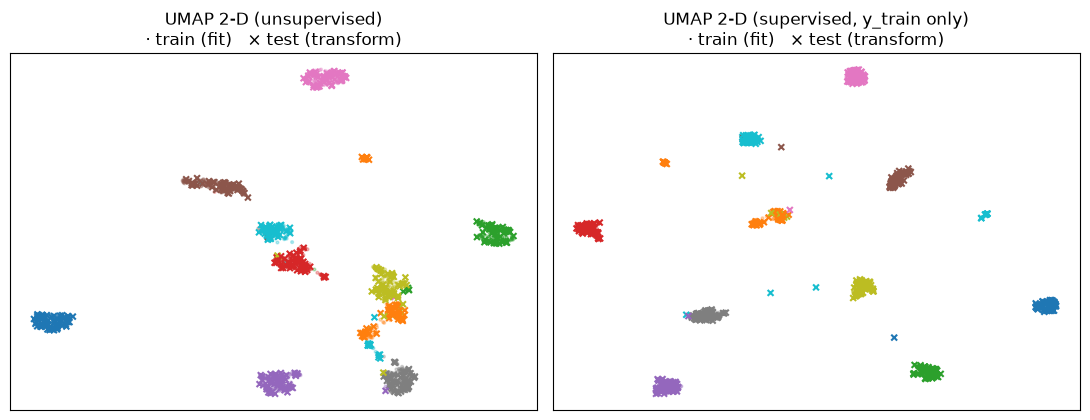

In [37]:
idx_tr, idx_te = train_test_split(np.arange(len(X_digits)), test_size=0.3, stratify=y_digits, random_state=SEED)
Xd_tr, Xd_te, yd_tr, yd_te = X_digits[idx_tr], X_digits[idx_te], y_digits[idx_tr], y_digits[idx_te]

transform_rows = {}
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xd_tr, yd_tr)
transform_rows["raw 64-D pixels (no reduction)"] = {"test accuracy": knn_raw.score(Xd_te, yd_te), "dimensions": 64}
pca_2 = PCA(n_components=2).fit(Xd_tr)
transform_rows["PCA 2-D"] = {"test accuracy": KNeighborsClassifier(n_neighbors=5).fit(pca_2.transform(Xd_tr), yd_tr)
                             .score(pca_2.transform(Xd_te), yd_te), "dimensions": 2}
umap_models = {"UMAP 2-D (unsupervised)": umap.UMAP(random_state=SEED, n_jobs=1).fit(Xd_tr),
               "UMAP 2-D (supervised, y_train only)": umap.UMAP(random_state=SEED, n_jobs=1).fit(Xd_tr, y=yd_tr)}
transformed = {}
for name, reducer in umap_models.items():
    start = time.perf_counter()
    E_te = reducer.transform(Xd_te)
    transform_ms = (time.perf_counter() - start) * 1000
    transformed[name] = E_te
    acc = KNeighborsClassifier(n_neighbors=5).fit(reducer.embedding_, yd_tr).score(E_te, yd_te)
    transform_rows[name] = {"test accuracy": acc, "dimensions": 2, "transform ms (541 images)": transform_ms}
transform_table = pd.DataFrame(transform_rows).T
print(transform_table.round(3))
sup_acc = transform_table.loc["UMAP 2-D (supervised, y_train only)", "test accuracy"]
unsup_acc = transform_table.loc["UMAP 2-D (unsupervised)", "test accuracy"]
print(f"\nsupervised vs unsupervised UMAP on unseen digits: {sup_acc:.3f} vs {unsup_acc:.3f} ({sup_acc - unsup_acc:+.3f})")
print("→ labels shape the TRAINING map; they don't guarantee better placement of unseen points" if sup_acc <= unsup_acc
      else "→ the labels also helped place unseen points")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, (name, reducer) in zip(axes, umap_models.items()):
    ax.scatter(*reducer.embedding_.T, c=yd_tr, cmap="tab10", s=4, alpha=0.3)
    ax.scatter(*transformed[name].T, c=yd_te, cmap="tab10", s=18, marker="x")
    ax.set(title=f"{name}\n· train (fit)   × test (transform)", xticks=[], yticks=[])
plt.tight_layout()
plt.show()

**Speed: UMAP vs t-SNE.** Same input for both (the top 50 PCA components of Fashion-MNIST images, the usual preprocessing), growing sample sizes. `n_jobs=1` for UMAP because `random_state` is set; t-SNE uses its defaults.

In [38]:
speed_rows = []
for n in [2_000, 5_000, 10_000]:
    idx = rng.choice(60_000, size=n, replace=False)
    X50 = PCA(n_components=50, random_state=SEED).fit_transform(X_fashion_all[idx])
    start = time.perf_counter()
    TSNE(random_state=SEED).fit_transform(X50)
    tsne_s = time.perf_counter() - start
    start = time.perf_counter()
    umap.UMAP(random_state=SEED, n_jobs=1).fit_transform(X50)
    umap_s = time.perf_counter() - start
    speed_rows.append({"n images": n, "t-SNE seconds": tsne_s, "UMAP seconds": umap_s, "t-SNE / UMAP": tsne_s / umap_s})
speed_table = pd.DataFrame(speed_rows).set_index("n images")
print(speed_table.round(2))
growth = speed_table.iloc[-1] / speed_table.iloc[0]
print(f"\n5× more images → t-SNE {growth['t-SNE seconds']:.1f}× slower, UMAP {growth['UMAP seconds']:.1f}× slower "
      f"| at {speed_table.index[-1]:,} images UMAP is {speed_table['t-SNE / UMAP'].iloc[-1]:.1f}× "
      f"{'faster' if speed_table['t-SNE / UMAP'].iloc[-1] > 1 else 'slower (single-threaded here)'}")

          t-SNE seconds  UMAP seconds  t-SNE / UMAP
n images                                           
2000               1.96          2.31          0.85
5000               4.14          7.79          0.53
10000              9.90          6.76          1.46

5× more images → t-SNE 5.1× slower, UMAP 2.9× slower | at 10,000 images UMAP is 1.5× faster


Timings depend on your CPU and threads. Read the **growth** numbers: the method whose time grows more slowly wins as data gets bigger. Without `random_state`, UMAP can also use all CPU cores, and GPU versions (cuML) handle millions of points.

### ✍️ Your Turn

You want a UMAP map that shows more **global** structure (how clusters relate), and you don't mind losing fine detail. Which parameter do you **increase**? Store its name as a string.

In [39]:
param_to_increase = None  # TODO: "n_neighbors", "min_dist" or "n_components"?
check("param_to_increase", param_to_increase, "n_neighbors", hint="Which parameter defines how large a 'local' neighbourhood is?")

⏳ param_to_increase: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
param_to_increase = "n_neighbors"
check("param_to_increase", param_to_increase, "n_neighbors")
```

A bigger `n_neighbors` builds the graph from larger neighbourhoods, so the layout reflects broader structure. `min_dist` only changes how tightly points pack; it doesn't change which points are connected.
</details>

> 💡 **Interview angle:** "t-SNE or UMAP?" — both preserve local neighbourhoods and distort global geometry. UMAP scales better to large data (its runtime grows more slowly), supports `transform` on new data, supervised/semi-supervised modes and any output dimension, so it's the default for big data and pipelines; t-SNE (or openTSNE) remains excellent for publication-quality 2-D maps. Neither map's cluster sizes or gaps should be read literally.

## 13. UMAP Before Clustering, With Caveats 🔴

Density-based clustering struggles in high dimensions (Notebook 13). A popular recipe is **UMAP to ~10 dimensions with `min_dist=0.0` and a larger `n_neighbors`, then cluster** (e.g. HDBSCAN). We test it on the digits, using the true labels **only** to grade the clusters with the Adjusted Rand Index (ARI: 1 = perfect agreement, 0 = random).

In [40]:
cluster_spaces = {"raw 64 pixels": X_digits, "PCA 10": PCA(n_components=10, random_state=SEED).fit_transform(X_digits)}
for seed in [0, 1, 2]:
    cluster_spaces[f"UMAP 10 (seed {seed})"] = umap.UMAP(n_components=10, n_neighbors=30, min_dist=0.0,
                                                          random_state=seed, n_jobs=1).fit_transform(X_digits)
cluster_rows = {}
for name, S in cluster_spaces.items():
    km_labels = KMeans(n_clusters=10, n_init=10, random_state=SEED).fit_predict(S)
    hdb_labels = HDBSCAN(min_cluster_size=40, copy=True).fit_predict(S)
    clustered = hdb_labels != -1
    cluster_rows[name] = {
        "KMeans ARI": adjusted_rand_score(y_digits, km_labels),
        "HDBSCAN ARI": adjusted_rand_score(y_digits, hdb_labels),
        "HDBSCAN clusters": len(set(hdb_labels) - {-1}),
        "HDBSCAN noise share": 1 - clustered.mean(),
        "silhouette in ORIGINAL 64-D (HDBSCAN labels)": (silhouette_score(X_digits[clustered], hdb_labels[clustered])
                                                         if len(set(hdb_labels[clustered])) > 1 else np.nan),
    }
cluster_table = pd.DataFrame(cluster_rows).T
print(cluster_table.round(3))
umap_ari = cluster_table.filter(like="UMAP", axis=0)["HDBSCAN ARI"]
print(f"\nHDBSCAN ARI: raw pixels {cluster_table.loc['raw 64 pixels', 'HDBSCAN ARI']:.3f} "
      f"(noise {cluster_table.loc['raw 64 pixels', 'HDBSCAN noise share']:.0%}) → UMAP {umap_ari.mean():.3f} ± {umap_ari.std():.3f} across 3 seeds")
seed_labels = [HDBSCAN(min_cluster_size=40, copy=True).fit_predict(cluster_spaces[f"UMAP 10 (seed {s})"]) for s in [0, 1, 2]]
print(f"agreement between seed 0 and seed 1 clusterings (ARI): {adjusted_rand_score(seed_labels[0], seed_labels[1]):.3f}")
sil = cluster_table["silhouette in ORIGINAL 64-D (HDBSCAN labels)"]
print(f"silhouette in the original 64-D space: UMAP + HDBSCAN labels {sil['UMAP 10 (seed 0)']:.3f} vs raw-pixel HDBSCAN {sil['raw 64 pixels']:.3f} "
      f"(computed only on the {1 - cluster_table.loc['raw 64 pixels', 'HDBSCAN noise share']:.0%} of points it clustered) → agreement with the "
      f"true digits and compactness in the original space {'disagree' if sil['UMAP 10 (seed 0)'] < sil['raw 64 pixels'] else 'agree'}, so never rely on a single check")

                  KMeans ARI  HDBSCAN ARI  HDBSCAN clusters  HDBSCAN noise share  silhouette in ORIGINAL 64-D (HDBSCAN labels)
raw 64 pixels          0.667        0.094               7.0                0.664                                         0.374
PCA 10                 0.654        0.120               6.0                0.594                                         0.286
UMAP 10 (seed 0)       0.901        0.811               9.0                0.000                                         0.159
UMAP 10 (seed 1)       0.900        0.809               9.0                0.000                                         0.160
UMAP 10 (seed 2)       0.835        0.828              10.0                0.005                                         0.173

HDBSCAN ARI: raw pixels 0.094 (noise 66%) → UMAP 0.816 ± 0.010 across 3 seeds
agreement between seed 0 and seed 1 clusterings (ARI): 0.997
silhouette in the original 64-D space: UMAP + HDBSCAN labels 0.159 vs raw-pixel HDBSCAN 0.374 (com

**It helps a lot here — now the caveats an interviewer wants to hear:**

- **UMAP distorts density.** Cluster sizes and how "tight" they look in the embedding are not the original densities, so density-based conclusions ("this segment is very homogeneous") must be checked in the original space. That's why we also computed the silhouette in the original 64-D space.
- **It can invent or merge clusters.** Small `n_neighbors` can tear one continuous group into pieces; noise can look like structure. Check stability across seeds and settings (we measured the seed-to-seed agreement).
- **We had labels to grade it.** In real unsupervised work you don't, so use stability, domain checks and downstream usefulness.
- **Fit on a sample, `transform` the rest** for big data, and version the fitted reducer with the clusters it produced.

> 💡 **Interview angle:** "Would you cluster on UMAP embeddings?" — yes as a pragmatic recipe (UMAP to ~10 dims, `min_dist=0`, larger `n_neighbors`, then HDBSCAN), but validate: clusters stable across seeds/parameters, sensible in the original feature space, and never interpret sizes or distances from the embedding. It is exploratory segmentation, not ground truth.

## 14. A Fair Head-to-Head: PCA vs t-SNE vs UMAP 🟡

Pretty pictures are easy to over-interpret. We compare the three methods **with numbers**, on the same 5,000 real Fashion-MNIST images (a stratified sample of the official training set), each producing 2 dimensions:

- **Trustworthiness (k=10)** against the original 784-pixel space: local neighbourhoods kept.
- **5-NN accuracy** in the 2-D map (5-fold CV): do same-class items stay together? (The embeddings are fitted without labels.)
- **Global structure:** Spearman correlation of the 45 class-centroid distances with the original space.
- **Runtime** (including the PCA-50 step for t-SNE and UMAP) and whether new points can be embedded.

      seconds trustworthiness k=10 5-NN accuracy in 2-D Spearman: global class distances can embed new points
PCA     0.009                0.913                0.522                            0.975                 True
t-SNE   6.581                0.989                0.788                            0.893                False
UMAP    3.215                0.980                0.747                            0.913                 True

5-NN accuracy on all 784 raw pixels, for reference: 0.796
best local structure (trustworthiness): t-SNE | best class grouping (5-NN): t-SNE | best global layout (Spearman): PCA | fastest: PCA


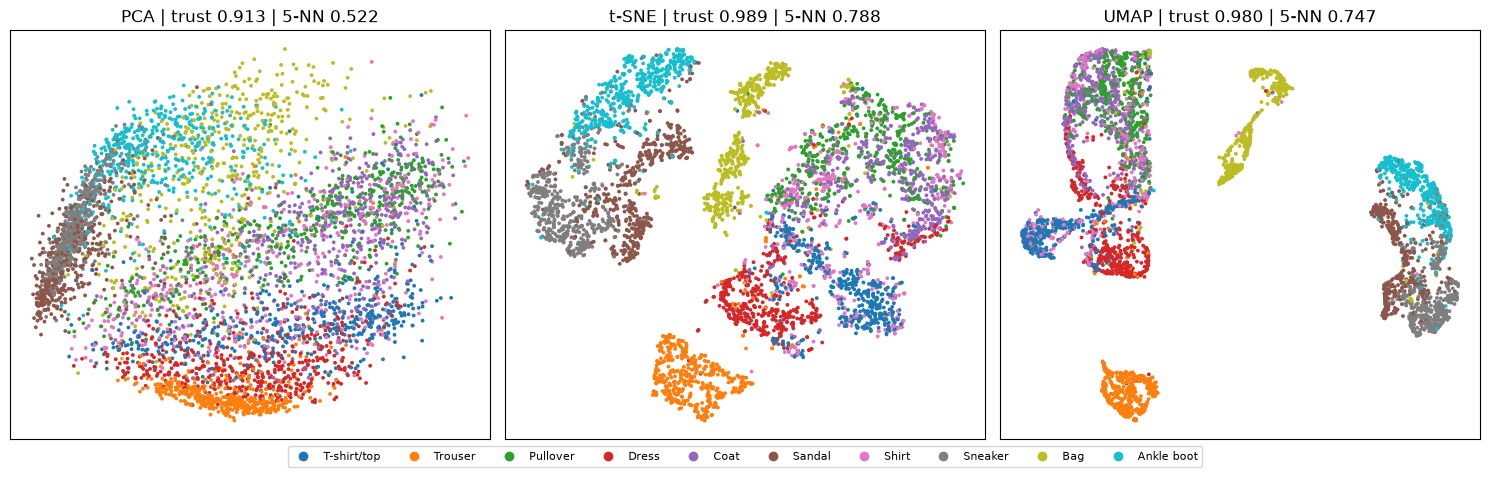

In [41]:
cmp_idx, _ = train_test_split(np.arange(60_000), train_size=5_000, stratify=y_fashion_all[:60_000], random_state=SEED)
X_cmp, y_cmp = X_fashion_all[cmp_idx], y_fashion_all[cmp_idx]
cmp_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
raw_cmp_cd = centroid_distances(X_cmp, y_cmp)


def run_pca():
    return PCA(n_components=2, random_state=SEED).fit_transform(X_cmp)


def run_tsne():
    return TSNE(random_state=SEED).fit_transform(PCA(n_components=50, random_state=SEED).fit_transform(X_cmp))


def run_umap():
    return umap.UMAP(random_state=SEED, n_jobs=1).fit_transform(PCA(n_components=50, random_state=SEED).fit_transform(X_cmp))


cmp_rows, cmp_maps = {}, {}
for name, runner, can_transform in [("PCA", run_pca, True), ("t-SNE", run_tsne, False), ("UMAP", run_umap, True)]:
    start = time.perf_counter()
    E = runner()
    seconds = time.perf_counter() - start
    cmp_maps[name] = E
    cmp_rows[name] = {"seconds": seconds, "trustworthiness k=10": trustworthiness(X_cmp, E, n_neighbors=10),
                      "5-NN accuracy in 2-D": knn_accuracy(E, y_cmp, cmp_folds),
                      "Spearman: global class distances": spearmanr(raw_cmp_cd, centroid_distances(E, y_cmp)).statistic,
                      "can embed new points": can_transform}
cmp_table = pd.DataFrame(cmp_rows).T
print(cmp_table.to_string(float_format=lambda v: f"{v:.3f}"))
print(f"\n5-NN accuracy on all 784 raw pixels, for reference: {knn_accuracy(X_cmp, y_cmp, cmp_folds):.3f}")

numeric = cmp_table.drop(columns="can embed new points").astype(float)
print(f"best local structure (trustworthiness): {numeric['trustworthiness k=10'].idxmax()} | "
      f"best class grouping (5-NN): {numeric['5-NN accuracy in 2-D'].idxmax()} | "
      f"best global layout (Spearman): {numeric['Spearman: global class distances'].idxmax()} | "
      f"fastest: {numeric['seconds'].idxmin()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, E) in zip(axes, cmp_maps.items()):
    ax.scatter(*E.T, c=y_cmp, cmap="tab10", s=3)
    ax.set(title=f"{name} | trust {numeric.loc[name, 'trustworthiness k=10']:.3f} | 5-NN {numeric.loc[name, '5-NN accuracy in 2-D']:.3f}",
           xticks=[], yticks=[])
handles = [plt.Line2D([], [], marker="o", ls="", color=plt.cm.tab10(c / 9), label=fashion_names[c]) for c in range(10)]
fig.legend(handles=handles, loc="lower center", ncol=10, fontsize=8, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

**Reading the table:** a linear 2-D shadow (PCA) is fast and keeps the rough global arrangement, but loses many neighbourhoods (lower trustworthiness and a much lower 2-D kNN accuracy). t-SNE and UMAP keep neighbourhoods far better, which is why their maps show separated clothing groups, and they pay for it in runtime and interpretability. No single number wins everything: pick by the job (compression and model features → PCA; a figure → t-SNE or UMAP; new data or pipelines → UMAP or PCA).

> 💡 **Interview angle:** "How do you evaluate a 2-D embedding?" — never by eye alone: trustworthiness/continuity for neighbourhood preservation, kNN accuracy (or cluster metrics) in the embedding if labels exist, correlation of global distances, stability across seeds, and runtime/transform needs. Report the numbers next to the plot.

## 🔧 Build It From Scratch

**PCA via the SVD of the centered data**, the way scikit-learn's `svd_solver="full"` does it:

1. $\mu$ = column means; $X_c = X - \mu$.
2. $X_c = U \Sigma V^\top$ (`np.linalg.svd(..., full_matrices=False)`).
3. **Sign rule** (`svd_flip`): flip each row of $V^\top$ so its largest-magnitude entry is positive, making the output deterministic.
4. `explained_variance_` $= s^2/(n-1)$; `explained_variance_ratio_` = that divided by the total over **all** components.
5. `transform`: $Z = (X - \mu)\,V_k^\top$, divided by $\sqrt{\lambda}$ if `whiten`.
6. `inverse_transform`: $\hat X = Z\,(\sqrt{\lambda}\text{ if whiten})\,V_k + \mu$.

We assert everything matches `sklearn.decomposition.PCA` on two real datasets: Fashion-MNIST (n > d) and the Olivetti faces (n < d).

In [42]:
class ScratchPCA:
    def __init__(self, n_components, whiten=False):
        self.n_components = n_components
        self.whiten = whiten

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        n = X.shape[0]
        self.mean_ = X.mean(axis=0)
        U, s, Vt = np.linalg.svd(X - self.mean_, full_matrices=False)
        biggest = np.argmax(np.abs(Vt), axis=1)                      # sign rule: largest |entry| of each component > 0
        signs = np.sign(Vt[np.arange(len(Vt)), biggest])
        Vt = Vt * signs[:, None]
        variance = s ** 2 / (n - 1)
        k = self.n_components
        self.components_ = Vt[:k]
        self.singular_values_ = s[:k]
        self.explained_variance_ = variance[:k]
        self.explained_variance_ratio_ = variance[:k] / variance.sum()
        return self

    def transform(self, X):
        Z = (np.asarray(X, dtype=np.float64) - self.mean_) @ self.components_.T
        return Z / np.sqrt(self.explained_variance_) if self.whiten else Z

    def inverse_transform(self, Z):
        W = self.components_ * np.sqrt(self.explained_variance_)[:, None] if self.whiten else self.components_
        return Z @ W + self.mean_


cases = [("Fashion-MNIST 3,000 × 784", X_fashion_all[:3_000].astype(np.float64), X_fashion_all[3_000:3_500].astype(np.float64), 40),
         ("Olivetti faces 300 × 4,096", Xfc_tr, Xfc_te, 100)]
for label, X_fit, X_new, k in cases:
    for whiten in [False, True]:
        ours = ScratchPCA(n_components=k, whiten=whiten).fit(X_fit)
        ref = PCA(n_components=k, whiten=whiten, svd_solver="full").fit(X_fit)
        assert np.allclose(ours.mean_, ref.mean_)
        assert np.allclose(ours.components_, ref.components_, atol=1e-8)
        assert np.allclose(ours.explained_variance_, ref.explained_variance_, rtol=1e-8)
        assert np.allclose(ours.explained_variance_ratio_, ref.explained_variance_ratio_, rtol=1e-8)
        assert np.allclose(ours.singular_values_, ref.singular_values_, rtol=1e-8)
        Z_ours, Z_ref = ours.transform(X_new), ref.transform(X_new)
        assert np.allclose(Z_ours, Z_ref, atol=1e-6)
        assert np.allclose(ours.inverse_transform(Z_ours), ref.inverse_transform(Z_ref), atol=1e-6)
    print(f"✅ {label}: components, explained variance (ratio), singular values, transform and inverse_transform "
          f"match sklearn (k={k}, whiten False & True)")

default_solver = PCA(n_components=10).fit(cases[0][1])
cos_default = np.abs((ScratchPCA(10).fit(cases[0][1]).components_ * default_solver.components_).sum(axis=1))
assert cos_default.min() > 0.99999
print(f"✅ the default solver ('{default_solver._fit_svd_solver}') finds the same top 10 directions (min |cos| {cos_default.min():.7f}); "
      f"it is a different algorithm, so tiny floating-point differences are expected")

✅ Fashion-MNIST 3,000 × 784: components, explained variance (ratio), singular values, transform and inverse_transform match sklearn (k=40, whiten False & True)


✅ Olivetti faces 300 × 4,096: components, explained variance (ratio), singular values, transform and inverse_transform match sklearn (k=100, whiten False & True)
✅ the default solver ('randomized') finds the same top 10 directions (min |cos| 1.0000000); it is a different algorithm, so tiny floating-point differences are expected


**Optional extra: power iteration for the first component.** Repeatedly multiplying a random vector by the covariance matrix amplifies its component along the top eigenvector, because $S^t v = \sum_j \lambda_j^t (v^\top e_j)\, e_j$ and $\lambda_1^t$ wins. We never form $S$: $S v \propto X_c^\top (X_c v)$. Convergence speed depends on the eigengap $\lambda_2/\lambda_1$.

In [43]:
def first_component_power_iteration(X, max_iter=1_000, tol=1e-12, seed=SEED):
    Xc = np.asarray(X, dtype=np.float64) - np.mean(X, axis=0)
    v = np.random.default_rng(seed).normal(size=Xc.shape[1])
    v /= np.linalg.norm(v)
    for iteration in range(1, max_iter + 1):
        w = Xc.T @ (Xc @ v)                      # S·v up to the constant 1/(n−1)
        w /= np.linalg.norm(w)
        converged = 1 - abs(w @ v) < tol
        v = w
        if converged:
            break
    eigenvalue = np.sum((Xc @ v) ** 2) / (len(Xc) - 1)   # Rayleigh quotient = variance along v
    return v * np.sign(v[np.argmax(np.abs(v))]), eigenvalue, iteration


X_power = cases[0][1]
v1, lam1, iters = first_component_power_iteration(X_power)
ref_power = PCA(n_components=2, svd_solver="full").fit(X_power)
assert abs(v1 @ ref_power.components_[0]) > 0.9999 and np.isclose(lam1, ref_power.explained_variance_[0], rtol=1e-6)
print(f"✅ power iteration: |cos| with sklearn PC1 = {abs(v1 @ ref_power.components_[0]):.8f}, eigenvalue {lam1:.4f} "
      f"vs {ref_power.explained_variance_[0]:.4f}, {iters} iterations (eigengap λ2/λ1 = "
      f"{ref_power.explained_variance_[1] / ref_power.explained_variance_[0]:.3f})")

✅ power iteration: |cos| with sklearn PC1 = 1.00000000, eigenvalue 19.9083 vs 19.9083, 20 iterations (eigengap λ2/λ1 = 0.626)


Exact equality is possible here because PCA is **deterministic** once the sign convention is fixed. (For more components, deflate: subtract $\lambda_1 v_1 v_1^\top$ and repeat, or use block methods like randomized SVD.)

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Supervised UMAP (or any reducer) fitted on the test rows

Fitting the reducer on all rows, labels included, lets the test labels shape the embedding. The score looks amazing and is meaningless.

In [44]:
leaky_embedding = umap.UMAP(random_state=SEED, n_jobs=1).fit_transform(X_digits, y=y_digits)   # sees test labels!
leaky_acc = KNeighborsClassifier(n_neighbors=5).fit(leaky_embedding[idx_tr], yd_tr).score(leaky_embedding[idx_te], yd_te)
print(f"❌ supervised UMAP fitted on train + test labels: test accuracy {leaky_acc:.3f}")
print(f"✅ fitted on training rows only, test rows via transform (Section 12): {sup_acc:.3f}")

❌ supervised UMAP fitted on train + test labels: test accuracy 0.998
✅ fitted on training rows only, test rows via transform (Section 12): 0.972


### ❌ Pitfall 2 — Fitting a separate PCA on the test set

A new PCA on test data learns *different* axes (and signs), so the trained model receives features that mean something else. No error, just wrong answers.

In [45]:
pca20_train = PCA(n_components=20).fit(Xd_tr)
scaler20 = StandardScaler().fit(pca20_train.transform(Xd_tr))
clf20 = LogisticRegression(max_iter=5000).fit(scaler20.transform(pca20_train.transform(Xd_tr)), yd_tr)
wrong = clf20.score(scaler20.transform(PCA(n_components=20).fit(Xd_te).transform(Xd_te)), yd_te)
right = clf20.score(scaler20.transform(pca20_train.transform(Xd_te)), yd_te)
print(f"❌ PCA refitted on the test set: accuracy {wrong:.3f}")
print(f"✅ the training PCA's transform (better: one Pipeline): accuracy {right:.3f}")

❌ PCA refitted on the test set: accuracy 0.526
✅ the training PCA's transform (better: one Pipeline): accuracy 0.950


### ❌ Pitfall 3 — TruncatedSVD on dense, uncentered data, treated as PCA

In [46]:
X_dense = X_fashion_all[:3_000].astype(np.float64)
mean_image = X_dense.mean(axis=0)
tsvd_raw = TruncatedSVD(n_components=2, algorithm="arpack").fit(X_dense)
pca_ref = PCA(n_components=2, svd_solver="full").fit(X_dense)
print(f"❌ TruncatedSVD component 0 vs the mean image: |cos| = {abs(tsvd_raw.components_[0] @ mean_image) / np.linalg.norm(mean_image):.3f}; "
      f"|cos| with PCA's PC1 = {abs(tsvd_raw.components_[0] @ pca_ref.components_[0]):.3f}")
tsvd_centered = TruncatedSVD(n_components=2, algorithm="arpack").fit(X_dense - mean_image)
print(f"✅ center first (or use PCA): |cos| with PCA's PC1 = {abs(tsvd_centered.components_[0] @ pca_ref.components_[0]):.6f}, "
      f"PC2 = {abs(tsvd_centered.components_[1] @ pca_ref.components_[1]):.6f}")

❌ TruncatedSVD component 0 vs the mean image: |cos| = 0.998; |cos| with PCA's PC1 = 0.876
✅ center first (or use PCA): |cos| with PCA's PC1 = 1.000000, PC2 = 1.000000


### ❌ Pitfall 4 — Comparing components without handling the sign

In [47]:
Z_std = StandardScaler().fit_transform(X_wine)
eigenvalues, eigenvectors = np.linalg.eigh(np.cov(Z_std, rowvar=False))
manual_components = eigenvectors[:, np.argsort(eigenvalues)[::-1]].T          # all 13, largest variance first
sk_components = PCA().fit(Z_std).components_
flipped = int((np.sign((manual_components * sk_components).sum(axis=1)) < 0).sum())
print(f"❌ np.allclose(manual, sklearn) = {np.allclose(manual_components, sk_components)} ({flipped} of 13 components have the opposite sign)")
signs = np.sign((manual_components * sk_components).sum(axis=1))
print(f"✅ after aligning signs: np.allclose = {np.allclose(manual_components * signs[:, None], sk_components, atol=1e-8)}")

❌ np.allclose(manual, sklearn) = False (8 of 13 components have the opposite sign)
✅ after aligning signs: np.allclose = True


### ❌ Pitfall 5 — A perplexity as large as the dataset

In [48]:
try:
    TSNE(perplexity=30, random_state=SEED).fit_transform(X_digits[:25])
except ValueError as err:
    print("❌ ValueError:", err)
small_map = TSNE(perplexity=5, random_state=SEED).fit_transform(X_digits[:25])
print(f"✅ perplexity=5 on 25 points works: embedding shape {small_map.shape}. Rule of thumb: perplexity well below n (5–50 for typical data).")

❌ ValueError: perplexity (30) must be less than n_samples (25)


✅ perplexity=5 on 25 points works: embedding shape (25, 2). Rule of thumb: perplexity well below n (5–50 for typical data).


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — The covariance matrix by hand
Center `X_ex` and compute its **sample covariance matrix** (`ddof=1`) with matrix multiplication, without `np.cov`.

In [49]:
X_ex = np.array([[1.0, 2.0], [3.0, 6.0], [5.0, 10.0]])
cov_ex = None  # TODO
check("cov_ex", cov_ex, [[4.0, 8.0], [8.0, 16.0]], hint="Xc = X_ex - X_ex.mean(axis=0); Xc.T @ Xc / (len(X_ex) - 1)")

⏳ cov_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_ex = np.array([[1.0, 2.0], [3.0, 6.0], [5.0, 10.0]])
Xc = X_ex - X_ex.mean(axis=0)
cov_ex = Xc.T @ Xc / (len(X_ex) - 1)
check("cov_ex", cov_ex, [[4.0, 8.0], [8.0, 16.0]])
```
All three points lie on the line y = 2x, so the matrix has rank 1: one component explains 100% of the variance.
</details>

### 🟢 Exercise 2 — Scores on the first component
For the same `X_ex`, the first principal component is `pc1_ex = [1, 2] / √5`. Compute the three **scores** (projections of the centered rows onto it).

In [50]:
pc1_ex = np.array([1.0, 2.0]) / np.sqrt(5)
scores_ex = None  # TODO
check("scores_ex", scores_ex, [-4.4721360, 0.0, 4.4721360], hint="(X_ex - X_ex.mean(axis=0)) @ pc1_ex")

⏳ scores_ex: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pc1_ex = np.array([1.0, 2.0]) / np.sqrt(5)
scores_ex = (X_ex - X_ex.mean(axis=0)) @ pc1_ex
check("scores_ex", scores_ex, [-4.4721360, 0.0, 4.4721360])
```
The centered rows are `[-2, -4]`, `[0, 0]` and `[2, 4]`; `[2, 4] · [1, 2]/√5 = 10/√5 ≈ 4.472`. Their variance, 20, is the covariance matrix's top eigenvalue.
</details>

### 🟢 Exercise 3 — Neighbourhood preservation
Each row of `nn_high` lists a point's 2 nearest neighbours in the original space; `nn_low` lists them in an embedding. Compute the **average fraction of neighbours kept** (the idea behind trustworthiness).

In [51]:
nn_high = np.array([[1, 2], [0, 2], [1, 0], [2, 1]])
nn_low = np.array([[2, 1], [0, 3], [1, 3], [0, 1]])
kept_fraction = None  # TODO
check("kept_fraction", kept_fraction, 0.625, hint="For each row: len(set(high) & set(low)) / 2; then average.")

⏳ kept_fraction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nn_high = np.array([[1, 2], [0, 2], [1, 0], [2, 1]])
nn_low = np.array([[2, 1], [0, 3], [1, 3], [0, 1]])
kept_fraction = np.mean([len(set(h) & set(l)) / nn_high.shape[1] for h, l in zip(nn_high, nn_low)])
check("kept_fraction", kept_fraction, 0.625)
```
Per point: 1.0, 0.5, 0.5, 0.5. Trustworthiness refines this by weighting each intruder by how far away it really was (its rank in the original space).
</details>

### 🟡 Exercise 4 — PCA from the covariance matrix
Using `np.linalg.eigh` on the covariance of the **standardized** wine data `Z_std`, return the top 3 components as a `(3, 13)` array, ordered by decreasing eigenvalue and following scikit-learn's **sign rule** (largest-magnitude entry of each component positive).

In [52]:
def components_from_covariance(Z, k):
    return None  # TODO


check("components_from_covariance", components_from_covariance(Z_std, 3), PCA(n_components=3).fit(Z_std).components_,
      hint="eigh returns ascending eigenvalues; reorder, take the top k eigenvector COLUMNS as rows, then flip signs.")

⏳ components_from_covariance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def components_from_covariance(Z, k):
    values, vectors = np.linalg.eigh(np.cov(Z, rowvar=False))
    top = vectors[:, np.argsort(values)[::-1][:k]].T                  # eigenvectors are columns → rows
    signs = np.sign(top[np.arange(k), np.argmax(np.abs(top), axis=1)])
    return top * signs[:, None]


check("components_from_covariance", components_from_covariance(Z_std, 3), PCA(n_components=3).fit(Z_std).components_)
```
The two classic bugs: taking rows of `vectors` instead of columns, and forgetting that `eigh` sorts eigenvalues in **ascending** order.
</details>

### 🟡 Exercise 5 — Reconstruction error curve
`pca_ex5` is fitted on the digits training rows. Using only its `components_` and `mean_` (NumPy), compute the **mean squared reconstruction error per pixel** on `Xd_te` for `k = 5, 10, 20`, as an array of 3 numbers.

In [53]:
pca_ex5 = PCA(n_components=20).fit(Xd_tr)
recon_mse = None  # TODO


def _reference_mse(k):
    p = PCA(n_components=k).fit(Xd_tr)
    return np.mean((Xd_te - p.inverse_transform(p.transform(Xd_te))) ** 2)


check("recon_mse", recon_mse, [_reference_mse(k) for k in [5, 10, 20]],
      hint="For each k: W = components_[:k]; Xc = Xd_te - mean_; np.mean((Xc - Xc @ W.T @ W) ** 2)")

⏳ recon_mse: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pca_ex5 = PCA(n_components=20).fit(Xd_tr)
Xc_te = Xd_te - pca_ex5.mean_
recon_mse = np.array([np.mean((Xc_te - Xc_te @ pca_ex5.components_[:k].T @ pca_ex5.components_[:k]) ** 2)
                      for k in [5, 10, 20]])


def _reference_mse(k):
    p = PCA(n_components=k).fit(Xd_tr)
    return np.mean((Xd_te - p.inverse_transform(p.transform(Xd_te))) ** 2)


check("recon_mse", recon_mse, [_reference_mse(k) for k in [5, 10, 20]])
```
The first k components of a 20-component PCA equal a k-component PCA, so one fit serves the whole curve. The error falls as k grows.
</details>

### 🔴 Exercise 6 — Whitened PCA transform from scratch (interview classic)
Implement `pca_whiten_transform(X_train, X_new, k)` with NumPy's SVD: fit on `X_train`, return the **whitened** scores of `X_new` (unit variance per component), with scikit-learn's sign rule. It must match `PCA(k, whiten=True)` on the digits.

In [54]:
def pca_whiten_transform(X_train, X_new, k):
    return None  # TODO: return an (n_new, k) array


check("pca_whiten_transform", pca_whiten_transform(Xd_tr, Xd_te, 10),
      PCA(n_components=10, whiten=True).fit(Xd_tr).transform(Xd_te),
      hint="center → svd → sign-flip rows of Vt → scores (X_new - mean) @ Vt[:k].T → divide by sqrt(s[:k]**2 / (n-1)).")

⏳ pca_whiten_transform: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def pca_whiten_transform(X_train, X_new, k):
    mean = X_train.mean(axis=0)
    _, s, Vt = np.linalg.svd(X_train - mean, full_matrices=False)
    Vt = Vt * np.sign(Vt[np.arange(len(Vt)), np.argmax(np.abs(Vt), axis=1)])[:, None]
    std = s[:k] / np.sqrt(len(X_train) - 1)            # sqrt of the explained variance
    return (X_new - mean) @ Vt[:k].T / std


check("pca_whiten_transform", pca_whiten_transform(Xd_tr, Xd_te, 10),
      PCA(n_components=10, whiten=True).fit(Xd_tr).transform(Xd_te))
```
Talk through: center with the **training** mean, the SVD's cost O(n·d·min(n, d)), why the sign rule is needed for reproducibility, and that whitening divides by $s/\sqrt{n-1}$ (the component's standard deviation), not by $s$.
</details>

## 🚀 Mini Project: Compress-and-Classify Fashion-MNIST

**Goal:** a product team wants to store compact image features and retrain a clothing classifier quickly. **How many PCA components keep test accuracy within 1 percentage point of the model trained on all 784 pixels?** Report accuracy, fit time, prediction time and memory, then draw a UMAP map of the same data and write down what it shows, with numbers.

**Protocol (no leakage):** 20,000 training images and 5,000 validation images, both from the official training set and disjoint; the official 10,000 test images are used **once** at the end. PCA is always fitted on the training images only (inside a pipeline). Classifier: logistic regression (`C=0.1`), fast and a good fit for "compressed features into a linear model".

**Steps:** split → full-pixel baseline → component sweep on validation → choose k → one test evaluation → UMAP map → computed observations.

### Step 1 — Splits

In [55]:
train_pool = np.arange(60_000)
proj_fit_idx, proj_val_idx = train_test_split(train_pool, train_size=20_000, test_size=5_000,
                                              stratify=y_fashion_all[train_pool], random_state=SEED)
proj_test_idx = np.arange(60_000, 70_000)                        # official test images
Xp_tr, yp_tr = X_fashion_all[proj_fit_idx], y_fashion_all[proj_fit_idx]
Xp_val, yp_val = X_fashion_all[proj_val_idx], y_fashion_all[proj_val_idx]
Xp_te, yp_te = X_fashion_all[proj_test_idx], y_fashion_all[proj_test_idx]
assert not set(proj_fit_idx) & set(proj_val_idx)
print(f"train {Xp_tr.shape} | validation {Xp_val.shape} | test {Xp_te.shape} | "
      f"train class counts {np.bincount(yp_tr).min()}–{np.bincount(yp_tr).max()}")

train (20000, 784) | validation (5000, 784) | test (10000, 784) | train class counts 2000–2000


### Step 2 — A measuring helper and the full-pixel baseline

In [56]:
def compress_and_classify(n_components, X_fit, y_fit, X_eval, y_eval):
    """Fit [PCA →] logistic regression; return accuracy, timings and memory for one setting."""
    steps = [] if n_components is None else [PCA(n_components=n_components, random_state=SEED)]
    model = make_pipeline(*steps, LogisticRegression(C=0.1, max_iter=2000))
    start = time.perf_counter()
    model.fit(X_fit, y_fit)
    fit_s = time.perf_counter() - start
    start = time.perf_counter()
    pred = model.predict(X_eval)
    predict_ms = (time.perf_counter() - start) * 1000
    dims = X_fit.shape[1] if n_components is None else n_components
    clf = model[-1]
    model_bytes = clf.coef_.nbytes + clf.intercept_.nbytes
    if n_components is not None:
        model_bytes += model[0].components_.nbytes + model[0].mean_.nbytes
    return {"dimensions": dims, "accuracy": accuracy_score(y_eval, pred), "fit s": fit_s,
            f"predict ms ({len(X_eval):,} images)": predict_ms,
            "stored features MB (float32)": len(X_eval) * dims * 4 / 1e6, "model KB": model_bytes / 1e3}, model, pred


baseline_val, _, _ = compress_and_classify(None, Xp_tr, yp_tr, Xp_val, yp_val)
print(pd.Series(baseline_val).round(4).to_string())

dimensions                      784.0000
accuracy                          0.8528
fit s                             1.0465
predict ms (5,000 images)         1.1969
stored features MB (float32)     15.6800
model KB                         31.4000


### Step 3 — Sweep the number of components (validation only)

            accuracy   fit s  predict ms (5,000 images)  stored features MB (float32)  model KB
dimensions                                                                                     
10            0.7606  0.2864                     1.3451                          0.20    34.936
20            0.8054  0.2780                     1.2906                          0.40    66.696
35            0.8210  0.3183                     1.4314                          0.70   114.336
50            0.8328  0.3241                     2.1030                          1.00   161.976
75            0.8414  0.3644                     1.7105                          1.50   241.376
100           0.8458  0.3596                     1.8774                          2.00   320.776
150           0.8494  0.3872                     2.0729                          3.00   479.576
200           0.8484  0.4664                     2.5603                          4.00   638.376
300           0.8500  0.5576            

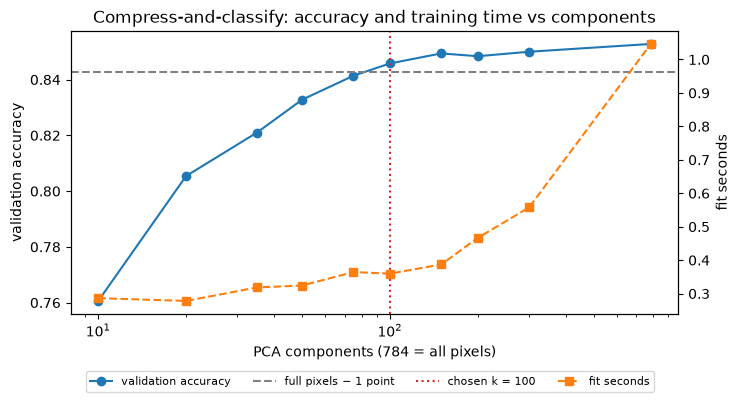

In [57]:
sweep_rows = [baseline_val]
for k in [10, 20, 35, 50, 75, 100, 150, 200, 300]:
    sweep_rows.append(compress_and_classify(k, Xp_tr, yp_tr, Xp_val, yp_val)[0])
sweep = pd.DataFrame(sweep_rows).set_index("dimensions").sort_index()
target = baseline_val["accuracy"] - 0.01
within = sweep[(sweep.index < 784) & (sweep["accuracy"] >= target)]
chosen_k = int(within.index.min()) if len(within) else 784
print(sweep.round(4))
print(f"\nfull-pixel validation accuracy {baseline_val['accuracy']:.4f} → target ≥ {target:.4f} → smallest k that qualifies: {chosen_k}")

fig, ax1 = plt.subplots(figsize=(7.5, 3.8))
ax1.plot(sweep.index, sweep["accuracy"], "o-", label="validation accuracy")
ax1.axhline(target, ls="--", c="grey", label="full pixels − 1 point")
ax1.axvline(chosen_k, ls=":", c="tab:red", label=f"chosen k = {chosen_k}")
ax1.set(xscale="log", xlabel="PCA components (784 = all pixels)", ylabel="validation accuracy")
ax2 = ax1.twinx()
ax2.plot(sweep.index, sweep["fit s"], "s--", c="tab:orange", label="fit seconds")
ax2.set_ylabel("fit seconds")
fig.legend(loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.06))
ax1.set_title("Compress-and-classify: accuracy and training time vs components")
plt.tight_layout()
plt.show()

### Step 4 — The one and only test evaluation

In [58]:
test_full, model_full, pred_full = compress_and_classify(None, Xp_tr, yp_tr, Xp_te, yp_te)
test_small, model_small, pred_small = compress_and_classify(chosen_k, Xp_tr, yp_tr, Xp_te, yp_te)
final = pd.DataFrame({"all 784 pixels": test_full, f"PCA {chosen_k}": test_small}).T
print(final.round(4))
test_gap = test_small["accuracy"] - test_full["accuracy"]
print(f"\ntest accuracy gap: {test_gap * 100:+.2f} points → "
      f"{'within' if test_gap >= -0.01 else 'outside'} the 1-point budget chosen on validation")

                dimensions  accuracy   fit s  predict ms (10,000 images)  stored features MB (float32)  model KB
all 784 pixels       784.0    0.8384  1.0761                      2.0473                         31.36    31.400
PCA 100              100.0    0.8337  0.3603                      3.2278                          4.00   320.776

test accuracy gap: -0.47 points → within the 1-point budget chosen on validation


### Step 5 — A UMAP map of the same images

10,000 training images, reduced to 50 PCA components first (fast, and removes pixel noise), then UMAP to 2-D. Labels are used only to colour the plot and to *measure* the map.

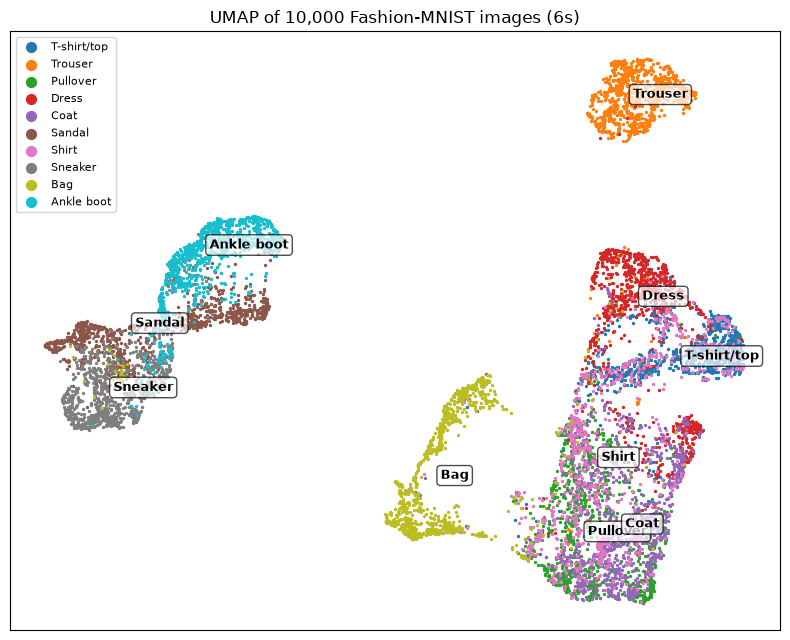

In [59]:
map_idx = proj_fit_idx[:10_000]
X_map50 = PCA(n_components=50, random_state=SEED).fit_transform(X_fashion_all[map_idx])
y_map = y_fashion_all[map_idx]
start = time.perf_counter()
E_map = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED, n_jobs=1).fit_transform(X_map50)
map_seconds = time.perf_counter() - start

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in range(10):
    pts = E_map[y_map == c]
    ax.scatter(*pts.T, s=2, color=plt.cm.tab10(c / 9), label=fashion_names[c])
    ax.annotate(fashion_names[c], np.median(pts, axis=0), fontsize=9, weight="bold",
                bbox={"boxstyle": "round", "fc": "white", "alpha": 0.7})
ax.set(title=f"UMAP of 10,000 Fashion-MNIST images ({map_seconds:.0f}s)", xticks=[], yticks=[])
ax.legend(markerscale=5, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

### Step 6 — Observations, computed

In [60]:
map_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
map_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=10), E_map, y_map, cv=map_folds)
map_recall = pd.Series(confusion_matrix(y_map, map_pred).diagonal() / np.bincount(y_map), index=fashion_names).sort_values()


def top_confusions(y_true, y_pred, n=3):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    sym = cm + cm.T
    pairs = [(sym[i, j], i, j) for i in range(10) for j in range(i + 1, 10)]
    return [(fashion_names[i], fashion_names[j], int(v)) for v, i, j in sorted(pairs, reverse=True)[:n]]


map_pairs = top_confusions(y_map, map_pred)
clf_pairs = top_confusions(yp_te, pred_small)
shared = {frozenset(p[:2]) for p in map_pairs} & {frozenset(p[:2]) for p in clf_pairs}
trust_map = trustworthiness(X_map50[:5000], E_map[:5000], n_neighbors=10)

predict_col = "predict ms (10,000 images)"
print(f"1. Compression: PCA {chosen_k} kept test accuracy at {test_small['accuracy']:.3f} vs {test_full['accuracy']:.3f} "
      f"({test_gap * 100:+.2f} points) with {784 / chosen_k:.1f}× less feature storage "
      f"({test_small['stored features MB (float32)']:.1f} MB vs {test_full['stored features MB (float32)']:.1f} MB for the test images) and "
      f"{test_full['fit s'] / test_small['fit s']:.1f}× faster training.")
print(f"   Costs: the model grows from {test_full['model KB']:.0f} KB to {test_small['model KB']:.0f} KB (it stores the PCA components), "
      f"and prediction takes {test_small[predict_col]:.1f} ms vs {test_full[predict_col]:.1f} ms "
      f"({'slower, because every image is projected first' if test_small[predict_col] > 1.2 * test_full[predict_col] else 'about the same here: the projection is a single matrix multiplication'}).")
print(f"2. Map quality: 10-NN accuracy inside the 2-D map {np.mean(map_pred == y_map):.3f}; "
      f"trustworthiness vs the 50-D PCA space {trust_map:.3f} (first 5,000 points).")
print(f"3. Best separated in the map: {', '.join(map_recall.index[-3:][::-1])} "
      f"(10-NN recall {map_recall.iloc[-1]:.2f}+); most mixed: {', '.join(map_recall.index[:3])} (recall {map_recall.iloc[0]:.2f}–{map_recall.iloc[2]:.2f}).")
print(f"4. Most overlapping pairs in the map: {map_pairs}")
print(f"5. Most confused pairs by the PCA-{chosen_k} classifier on the test set: {clf_pairs}")
print(f"6. {len(shared)} of the top 3 pairs are shared → the map "
      f"{'predicted where the classifier struggles' if shared else 'and the classifier disagree on what is hard'}"
      f"{': ' + ', '.join(' / '.join(sorted(p)) for p in shared) if shared else ''}.")

1. Compression: PCA 100 kept test accuracy at 0.834 vs 0.838 (-0.47 points) with 7.8× less feature storage (4.0 MB vs 31.4 MB for the test images) and 3.0× faster training.
   Costs: the model grows from 31 KB to 321 KB (it stores the PCA components), and prediction takes 3.2 ms vs 2.0 ms (slower, because every image is projected first).
2. Map quality: 10-NN accuracy inside the 2-D map 0.767; trustworthiness vs the 50-D PCA space 0.986 (first 5,000 points).
3. Best separated in the map: Trouser, Bag, Ankle boot (10-NN recall 0.94+); most mixed: Shirt, Coat, Pullover (recall 0.31–0.62).
4. Most overlapping pairs in the map: [('Pullover', 'Coat', 429), ('Pullover', 'Shirt', 369), ('T-shirt/top', 'Shirt', 336)]
5. Most confused pairs by the PCA-100 classifier on the test set: [('Pullover', 'Coat', 253), ('T-shirt/top', 'Shirt', 247), ('Coat', 'Shirt', 217)]
6. 2 of the top 3 pairs are shared → the map predicted where the classifier struggles: Coat / Pullover, Shirt / T-shirt/top.


**Stretch goals**
1. Replace logistic regression with an RBF SVM or HistGradientBoosting and redo the sweep: does the chosen k change?
2. Add `whiten=True` and tune `C` jointly with `n_components` in a `GridSearchCV` (Section 7's recipe).
3. Measure **peak memory** of fitting with `tracemalloc`, and train on all 60,000 images with `IncrementalPCA`.
4. Draw the map with supervised UMAP fitted on training images and `transform` the test images; compare 10-NN test accuracy in 2-D with the unsupervised map.
5. Repeat on MNIST digits (`fetch_openml(data_id=554)`): do digits need more or fewer components than clothes for the same 1-point budget?

### 🗣️ How to talk about this in an interview
- "I framed compression as a constraint: the smallest number of PCA components that keeps accuracy within one point of the full model, chosen on a validation split and confirmed once on the official test set."
- "PCA was fitted on training images only, inside the pipeline, so neither validation nor test data shaped the components."
- "I reported the trade-off in engineering units (fit time, prediction time, model size, feature storage), not just accuracy."
- "For exploration I used a UMAP map, but I backed each claim with numbers: kNN recall per class in the map and trustworthiness, and I checked that the classes overlapping in the map were the same ones the classifier confused."
- "I wouldn't read cluster sizes or gaps from the UMAP plot; those aren't preserved."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Walk me through PCA. What does it optimize?**

<details><summary>Show answer</summary>

- **30-second answer:** Center the data (standardize if units differ), compute the SVD of the centered matrix (or eigendecomposition of the covariance), sort directions by variance, keep the top k and project. It finds orthogonal directions that maximize projected variance, which is the same as minimizing squared reconstruction error.
- **Go deeper:** Lagrangian of $\max u^\top S u$ s.t. $\lVert u\rVert = 1$ gives $Su = \lambda u$; eigenvalue = variance along the component; training reconstruction SSE = $(n-1)\sum_{j>k}\lambda_j$. Scores $= U_k\Sigma_k$. Fit on training data only; `transform` others. Linear autoencoders trained with MSE learn the same subspace.
- **❌ Common wrong answer:** "PCA picks the most important original features." It builds new combinations of all features and ignores the labels.

</details>

**Q2. Eigendecomposition of the covariance matrix or SVD of the data?**

<details><summary>Show answer</summary>

- **30-second answer:** Same components and variances ($\lambda = s^2/(n-1)$). SVD is numerically more stable because it never forms $X^\top X$ (which squares the condition number), works directly when d > n, and gives scores for free. The covariance route is fine and fast when d is small and n is huge.
- **Go deeper:** Costs: covariance O(n·d² + d³), full SVD O(n·d·min(n,d)), randomized SVD O(n·d·k) for the top k. Signs are arbitrary; scikit-learn's `svd_flip` fixes them. We showed the Läuchli matrix losing its smallest singular value through $X^\top X$.
- **❌ Common wrong answer:** "SVD and eigendecomposition give different principal components."

</details>

**Q3. How do you choose the number of components?**

<details><summary>Show answer</summary>

- **30-second answer:** For compression or exploration, the smallest k reaching a variance target (e.g. 95%, `PCA(n_components=0.95)`) or a scree-plot elbow. If PCA feeds a model, tune k by cross-validating the whole pipeline, and consider the latency/memory budget.
- **Go deeper:** Variance kept ≠ predictive information (LDA beat PCA at 2 dims). Kaiser's eigenvalue > 1 rule applies to standardized data only. Probabilistic PCA supports Minka's MLE (`n_components="mle"`). In the mini project we chose k as "within 1 accuracy point" on validation.
- **❌ Common wrong answer:** "Always keep 2 or 3 components" or "choose k on the test set".

</details>

**Q4. Why standardize before PCA, and when shouldn't you?**

<details><summary>Show answer</summary>

- **30-second answer:** PCA maximizes variance, which depends on units; unscaled, the largest-unit feature becomes PC1 (proline explained ~99.8% of wine's variance). Standardize mixed-unit features, inside a pipeline. For same-unit features where magnitude matters (pixels, counts), standardizing can overweight near-constant, noisy columns.
- **Go deeper:** Standardized PCA = eigendecomposition of the correlation matrix. Robust scaling helps with outliers but doesn't make PCA robust; robust PCA or `MinCovDet` do.
- **❌ Common wrong answer:** "PCA is scale-invariant because it uses directions."

</details>

**Q5. PCA vs t-SNE vs UMAP: when do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** PCA is linear, fast, deterministic and invertible: use it for compression, denoising and model features. t-SNE is for 2-D/3-D visualization of local clusters. UMAP also visualizes local structure, scales better to big data, can `transform` new points, supports supervision and any output dimension, so it fits pipelines (e.g. before clustering).
- **Go deeper:** Measured on Fashion-MNIST: t-SNE and UMAP had far higher trustworthiness and 2-D kNN accuracy than PCA; PCA was fastest. Common recipe: PCA to ~50 dims, then t-SNE/UMAP. Evaluate embeddings with trustworthiness, kNN accuracy and seed stability.
- **❌ Common wrong answer:** "t-SNE and UMAP are better PCA, so use them as features for any model."

</details>

**Q6. Explain perplexity, the crowding problem, and why t-SNE uses a Student-t distribution.**

<details><summary>Show answer</summary>

- **30-second answer:** Perplexity ($2^{H}$) sets each point's Gaussian width so it has about that many effective neighbours. The crowding problem: there isn't enough room in 2-D to place all of a point's high-dimensional neighbours at the right distances. The heavy-tailed Student-t in low dimensions lets moderately far points sit much farther away, creating clear gaps.
- **Go deeper:** Objective: KL(P‖Q), which punishes separating neighbours more than merging distant points, hence local-not-global. Early exaggeration helps clusters form; Barnes–Hut makes it O(n log n); PCA initialization improves global stability. Perplexity must be < n; typical 5–50.
- **❌ Common wrong answer:** "Perplexity is the number of clusters."

</details>

**Q7. What can't you conclude from a t-SNE (or UMAP) plot?**

<details><summary>Show answer</summary>

- **30-second answer:** Cluster sizes, distances between clusters, and density are not reliable, and layouts can change with initialization and perplexity. You can conclude that points drawn together are usually neighbours in the original space.
- **Go deeper:** We measured it: a std-10 blob and a std-1 blob came out similar in size; the correlation of between-cluster distances changed with initialization and perplexity while kNN accuracy stayed stable (with the default PCA initialization, two seeds gave identical maps). Validate in the original space and with several runs. Also: t-SNE has no `transform`.
- **❌ Common wrong answer:** "The two clusters are far apart, so those groups are very different."

</details>

**Q8. How does UMAP work, and what do `n_neighbors` and `min_dist` do?**

<details><summary>Show answer</summary>

- **30-second answer:** UMAP builds a weighted k-nearest-neighbour graph (distances normalized per point by its nearest neighbour, combined with a fuzzy union), then optimizes a low-dimensional layout with cross-entropy using attraction along edges and negative sampling for repulsion. `n_neighbors` sets how local vs global the graph is; `min_dist` sets how tightly points pack.
- **Go deeper:** Approximate kNN via NN-descent, spectral initialization, SGD. Supports `transform`, supervised `fit(X, y)`, custom metrics, `n_components` > 2, and DensMAP to preserve some density. Setting `random_state` makes it single-threaded.
- **❌ Common wrong answer:** "UMAP preserves global distances, unlike t-SNE." It often keeps more coarse structure, but distances and densities are still distorted.

</details>

**Q9. PCA is linear. What do you do when the structure is nonlinear?**

<details><summary>Show answer</summary>

- **30-second answer:** Kernel PCA (PCA in an implicit feature space via a kernel matrix), manifold learners (Isomap, t-SNE, UMAP) or autoencoders. Kernel PCA separated the two rings that PCA couldn't, at O(n²) memory.
- **Go deeper:** Kernel PCA needs kernel choice/γ tuning and has only an approximate inverse (`fit_inverse_transform=True`); use `Nystroem` approximations to scale. Autoencoders with nonlinear layers generalize PCA; a linear autoencoder with MSE spans the PCA subspace.
- **❌ Common wrong answer:** "Add more components until PCA captures the nonlinearity."

</details>

### 💻 Coding

**Q10. Implement PCA in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  mu = X.mean(0); Xc = X - mu
  U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
  W = Vt[:k]; Z = Xc @ W.T                    # scores
  ratio = s[:k]**2 / (s**2).sum()             # explained variance ratio
  X_hat = Z @ W + mu                          # reconstruction
  ```
- **Go deeper:** Apply the sign rule for reproducibility, divide by $s/\sqrt{n-1}$ to whiten, use the training mean for new data, randomized SVD for big matrices, power iteration for just the first component. Our `ScratchPCA` matched scikit-learn exactly.
- **❌ Common wrong answer:** Forgetting to center, or using rows of `U` as the components (the directions are the rows of `Vt`).

</details>

**Q11. How do you use PCA with a classifier in scikit-learn without leakage?**

<details><summary>Show answer</summary>

- **30-second answer:** `GridSearchCV(make_pipeline(StandardScaler(), PCA(), LogisticRegression()), {"pca__n_components": [10, 20, 50, 100], "logisticregression__C": [0.1, 1, 10]}, cv=StratifiedKFold(5, shuffle=True))` on the training data, then evaluate `best_estimator_` once on the test set (or use nested CV).
- **Go deeper:** Every fold refits the scaler and PCA on its own training part. For big data swap in `IncrementalPCA` or randomized solvers; for text use `TruncatedSVD`. Report fit/predict time with accuracy.
- **❌ Common wrong answer:** `PCA().fit_transform(X_all)` first, then `train_test_split`.

</details>

### 🐛 Debugging Scenarios

**Q12. After adding PCA to a pipeline, accuracy dropped from 0.91 to 0.74. What would you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Scaling (a large-unit feature hijacking PC1), too few components, a model where variance isn't aligned with the label, and train/serve bugs like a PCA refitted on test data (we saw accuracy collapse in Pitfall 2).
- **Go deeper:** Plot cumulative explained variance, sweep `n_components` with CV, compare with LDA or feature selection, check for outliers rotating components, and confirm the same fitted transformer is used at inference (one serialized pipeline). Tree models often don't benefit from PCA at all.
- **❌ Common wrong answer:** "PCA always loses information, so remove it" without diagnosing.

</details>

**Q13. A stakeholder shows you a UMAP plot: "Segment A is huge and far from everything, so those customers are totally different." How do you respond?**

<details><summary>Show answer</summary>

- **30-second answer:** UMAP and t-SNE don't preserve cluster sizes, densities or between-cluster distances, so the picture alone can't support that. I'd check it in the original feature space: centroid distances, feature distributions per segment, and a classifier's ability to separate A from the rest.
- **Go deeper:** Re-run with different seeds, `n_neighbors` and `min_dist`; compute trustworthiness; count segment sizes directly; use PCA for a linear sanity check. Present the numbers alongside the map.
- **❌ Common wrong answer:** "Yes, the gap in the plot proves they are different."

</details>

**Q14. Your supervised UMAP features gave 99% test accuracy offline but 85% in production. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Most likely leakage: the reducer was fitted with labels on data that included the evaluation rows, so test points were pulled towards their true class (Pitfall 1). Production points get no labels, only `transform`.
- **Go deeper:** Fit reducers inside CV or on the training split only, evaluate with `transform` on held-out data, and check for distribution shift and a different `random_state`/version between training and serving. Store the fitted reducer with the model.
- **❌ Common wrong answer:** "Production data is noisier; retrain more often."

</details>

### 🏗️ Design

**Q15. Design an "embedding explorer" for 20 million product embeddings (768 dims) that shows a 2-D map and places new products daily.**

<details><summary>Show answer</summary>

- **30-second answer:** Offline: L2-normalize, fit PCA to ~50 dims (randomized or incremental), fit UMAP on a stratified sample (say 500k) with a cosine metric, and `transform` the rest in batches. Daily: `transform` new products with the stored PCA + UMAP models. Serve the 2-D coordinates from a tile/point-cloud viewer with metadata filters.
- **Go deeper:** Version the reducers (a refit changes every coordinate), monitor PCA reconstruction error and the share of new points far from the sample (drift), refit periodically and re-project. Use GPU UMAP (cuML) for large refits; float32 storage (20M × 2 = 160 MB). Label the UI to warn that distances between clusters aren't meaningful.
- **❌ Common wrong answer:** "Run t-SNE on all 20 million every day."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `PCA().fit(np.random.rand(100, 5)).explained_variance_ratio_.sum()` returns what?
<details><summary>Answer</summary>

`1.0` (up to rounding): with n > d and `n_components=None`, all 5 components are kept, so together they explain all the variance.
</details>

**2.** `hasattr(TSNE(), "transform")` — `True` or `False`?
<details><summary>Answer</summary>

**`False`.** t-SNE only has `fit` and `fit_transform`; it can't embed new points. UMAP and PCA have `transform`.
</details>

**3.** For `Z = PCA(n_components=3, whiten=True).fit_transform(X)`, what is `Z.var(axis=0, ddof=1)`?
<details><summary>Answer</summary>

`[1., 1., 1.]` — whitening divides each component's scores by its standard deviation.
</details>

**4.** On a **centered** dense matrix `Xc`, do `TruncatedSVD(n_components=2, algorithm="arpack")` and `PCA(n_components=2)` give the same components up to sign?
<details><summary>Answer</summary>

**Yes.** The only difference between them is centering: PCA centers, TruncatedSVD doesn't. On already-centered data they agree (Pitfall 3 shows it).
</details>

**5.** What happens with `TSNE(perplexity=30).fit_transform(X)` when `X` has 25 rows?
<details><summary>Answer</summary>

`ValueError: perplexity must be less than n_samples` — see Pitfall 5.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Decomposing signals in components (PCA, TruncatedSVD, IncrementalPCA, KernelPCA)](https://scikit-learn.org/stable/modules/decomposition.html) — every PCA variant used here, with the solvers
- [scikit-learn — Manifold learning](https://scikit-learn.org/stable/modules/manifold.html) — t-SNE and its practical tips
- [scikit-learn — trustworthiness](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.trustworthiness.html) — the neighbourhood-preservation metric from Sections 10–14
- [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/) — parameters, `transform`, supervised UMAP and clustering guides
- [Understanding UMAP (Google PAIR)](https://pair-code.github.io/understanding-umap/) — interactive visual explanation comparing UMAP and t-SNE

### 🎥 Videos
- [StatQuest (Josh Starmer) — Principal Component Analysis (PCA), Step-by-Step](https://www.youtube.com/watch?v=FgakZw6K1QQ) (~22 min) — the variance/SVD picture with clear drawings; watch before Sections 2–4
- [StatQuest (Josh Starmer) — t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM) (~12 min) — similarity scores, the t-distribution and perplexity; pairs with Section 10
- [StatQuest (Josh Starmer) — UMAP Dimension Reduction, Main Ideas!!!](https://www.youtube.com/watch?v=eN0wFzBA4Sc) (~19 min) — the neighbour graph and layout optimization; pairs with Section 12. Follow-up: [UMAP: Mathematical Details (clearly explained!!!)](https://www.youtube.com/watch?v=jth4kEvJ3P8) (~16 min)

### 📄 Papers
- [van der Maaten & Hinton (2008) — Visualizing Data using t-SNE](https://www.jmlr.org/papers/v9/vandermaaten08a.html) — the t-SNE paper (JMLR)
- [McInnes, Healy & Melville (2018) — UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction](https://arxiv.org/abs/1802.03426) — the UMAP paper
- [Wattenberg, Viégas & Johnson (2016) — How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) — interactive article behind Section 11
- [Shlens (2014) — A Tutorial on Principal Component Analysis](https://arxiv.org/abs/1404.1100) — a gentle derivation of PCA and its link to SVD

### 📘 Books & Courses
- [Mathematics for Machine Learning (free book)](https://mml-book.github.io/) — Chapter 10 derives PCA from both the variance and the reconstruction views
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 12 covers PCA for unsupervised learning

### 🏋️ Practice
- [Kaggle — Fashion MNIST dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist) — extend the mini project with other classifiers and reducers
- [Kaggle — Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer) — practice PCA + classifier pipelines on MNIST with a leaderboard

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Selection vs extraction | keep columns vs build new ones | `SelectKBest` vs `PCA` |
| PCA objective | max projected variance = min reconstruction error | $Su = \lambda u$; SSE $= (n-1)\sum_{j>k}\lambda_j$ |
| SVD route | stable, scores for free | $X_c = U\Sigma V^\top$, $\lambda = s^2/(n-1)$, `svd_solver="full"/"randomized"/"covariance_eigh"/"arpack"` |
| Choosing k | variance target or CV | `PCA(n_components=0.95)`, `GridSearchCV` on `pca__n_components` |
| Scaling | stop large-unit features dominating | `make_pipeline(StandardScaler(), PCA())` |
| Whitening | unit-variance, uncorrelated scores | `PCA(whiten=True)`: $z_j/\sqrt{\lambda_j}$ |
| Sparse / text | SVD without centering (LSA) | `TruncatedSVD(n_components=100)` |
| Out of memory | mini-batch PCA | `IncrementalPCA().partial_fit(batch)` |
| Nonlinear | PCA on a kernel matrix, O(n²) | `KernelPCA(kernel="rbf", gamma=...)` |
| t-SNE | keep neighbours in 2-D; no transform | `TSNE(perplexity=30)`; KL(P‖Q), Student-t |
| UMAP | graph-based map; transform, supervised | `umap.UMAP(n_neighbors=15, min_dist=0.1)`, `.transform`, `.fit(X, y)` |
| Don't read | sizes, gaps, densities in t-SNE/UMAP | check several seeds + original space |
| Evaluate embeddings | numbers, not pictures | `trustworthiness`, kNN accuracy, Spearman of distances, runtime |
| From scratch | SVD + sign rule | `Vt *= sign(Vt[i, argmax|Vt[i]|])` |

## ➡️ What's Next

**[15 · Anomaly Detection](15_Anomaly_Detection.ipynb)** — PCA's reconstruction error, Gaussian-mixture densities and nearest-neighbour distances all become ways to find the rare, strange points: fraud, failures and intrusions, evaluated when labels are scarce.